# Heston Model Calibration on Real Market Data 

This notebook calibrates the Heston stochastic volatility model to option quotes for a **single quote date**. It supports both calls and puts, computes model prices, converts model and market prices into Black implied volatilities, evaluates in-sample and holdout errors, and visualizes implied-volatility smiles and surfaces.


## Overview
This notebook calibrates the Heston (1993) stochastic volatility model to a single day of SPX option quotes (QUOTE_DATE = 2023-12-29), then checks the calibrated model for static no-arbitrage violations (butterfly and calendar spreads) on the implied total-variance surface.

### Pipeline:

**Data** — load SPX quotes, split into a train set (in-sample calibration) and a test holdout set (out-of-sample evaluation), both restricted to the target quote date.  
**Pricing** — Black-Scholes and Heston semi-analytic pricers (Fourier / characteristic-function integration, "Little Trap" formulation for numerical stability).  
**Calibration** — least-squares fit of the 5 Heston parameters to market prices (and, separately, to market implied vols).  
**Diagnostics** — RMSE/MAE on price and IV, 3D IV surfaces, 2D smiles, and static no-arbitrage checks (butterfly convexity and calendar monotonicity of total variance).

### The Heston model
Under the risk-neutral measure, the Heston (1993) model specifies the spot price $S_t$ and its instantaneous variance $v_t$ as the solution of the coupled SDEs

$$
\begin{aligned}
dS_t &= rS_t,dt + \sqrt{v_t}S_tdW_t^{S}, \\
dv_t &= \kappa(\theta - v_t)dt + \xi\sqrt{v_t}dW_t^{v}, \\
d\langle W^S, W^v\rangle_t = \rho dt
\end{aligned}
$$

with parameters:  
$v_0$	- initial variance  
$\kappa$	- speed of mean reversion of variance  
$\theta$	- long-run variance level  
$\xi$	- volatility of variance ("vol-of-vol")  
$\rho$	- correlation between the asset and variance Brownian motions  


## Heston semi-analytic pricer
The European call price is recovered from the model's characteristic function via the Heston (1993) / Gatheral-style Fourier inversion:

$$
C_{Heston} = S_0 P_1 - K e^{-rt} P_2, \qquad
P_j = \frac12 + \frac{1}{\pi}\int_0^\infty \operatorname{Re}!\left[\frac{e^{-i\phi\ln K},f_j(\phi)}{i\phi}\right]d\phi,\quad j=1,2
$$

where $f_j$ is the (log-price) characteristic function of the Heston model,

$$
f_j(\phi) = \exp!\big(C(\phi,t) + D(\phi,t),v_0 + i\phi\ln S_0\big)
$$

$$
\begin{aligned}
d &= \sqrt{(\rho\xi i\phi - b_j)^2 - \xi^2(2u_j i\phi - \phi^2)} \\
g &= \frac{b_j - \rho\xi i\phi - d}{b_j - \rho\xi i\phi + d} \\
C(\phi,t) &= ri\phi t + \frac{\kappa\theta}{\xi^2}\Big[(b_j - \rho\xi i\phi - d)t - 2\ln\Big(\frac{1-ge^{-dt}}{1-g}\Big)\Big] \\
D(\phi,t) &= \frac{b_j - \rho\xi i\phi - d}{\xi^2}\cdot\frac{1-e^{-dt}}{1-ge^{-dt}}
\end{aligned}
$$

with $(u_1,b_1)=(\tfrac12,\ \kappa-\rho\xi)$ and $(u_2,b_2)=(-\tfrac12,\ \kappa)$.

The $-d$ / $e^{-dt}$ sign choice above (vs. the textbook $+d$ / $e^{+dt}$ form used in the scalar heston_call helper) is the "Little Trap" reformulation (Albrecher et al., 2007): mathematically equivalent, but it avoids branch-cut discontinuities in the complex logarithm that make the naive formulation numerically unstable at long maturities / certain parameter combinations. The integral is evaluated with a truncated trapezoidal rule over $\phi \in (0,\text{integration_limit}]$ using n_phi points (rather than adaptive quadrature), which is what makes the vectorized pricer fast enough to call inside a least-squares loop.

Put prices follow from put-call parity, $P = C - S_0 + Ke^{-rt}$.

In [144]:
# ============================================================
# Import packages
# ============================================================

import numpy as np
import pandas as pd

from pathlib import Path
from scipy.optimize import least_squares, brentq
from scipy.stats import norm
from scipy.interpolate import griddata
from numpy.polynomial.legendre import leggauss

import matplotlib.pyplot as plt
import plotly.graph_objects as go

from nelson_siegel_svensson.calibrate import calibrate_nss_ols

import time
from scipy.integrate import quad, trapezoid, cumulative_trapezoid


# ============================================================
# Configuration
# ============================================================

DATA_PATH = Path('/Users/uran/Desktop/ErdosBootcamp/Project_Quant_Finance/Quant-Finance-project/Processed_data/surface_all.parquet')

TICKER = "SPX"
QUOTE_DATE = "2023-12-29"

HOLDOUT_FRAC = 0.2
MIN_VISIBLE = 6
SPLIT_SEED = 0

# # Heston integration settings
# UMAX = 200.0
# N_INT = 64        # 64 already matches a reference pricer to ~1e-6; raise to 128 for a final run

# # Implied-volatility inversion bounds
# IV_LOW = 1e-6
# IV_HIGH = 5.0

In [145]:
# ============================================================
# Load data and prepare
# ============================================================

df = pd.read_parquet(DATA_PATH)
df = df[df["ticker"] == TICKER].copy().reset_index(drop=True)
df["type"] = df["type"].astype(str).str.lower()
print(f"{TICKER}: {len(df):,} quotes over {df['quote_date'].nunique()} quote dates")

# ============================================================
# Train / holdout split
# ============================================================

def make_holdout(frame, frac=0.2, min_vis=6, seed=0):
    """
    Randomly select holdout quotes inside each ticker / quote_date / expire_date group, while keeping at least min_vis visible quotes per group.
    """
    rng = np.random.default_rng(seed)
    hold = pd.Series(False, index=frame.index)
    for _, sl in frame.groupby(["ticker", "quote_date", "expire_date"]):
        n = len(sl)
        n_hold = min(int(round(frac * n)), max(0, n - min_vis))
        if n_hold > 0:
            idx = rng.choice(sl.index.values, size=n_hold, replace=False)
            hold.loc[idx] = True
    return hold


df["is_holdout"] = make_holdout(df, frac=HOLDOUT_FRAC, min_vis=MIN_VISIBLE, seed=SPLIT_SEED)

# Day-level feature using visible data only
lvl = (df.loc[~df["is_holdout"]].groupby(["ticker", "quote_date"])["iv"].median().rename("day_level").reset_index())

df = df.merge(lvl, on=["ticker", "quote_date"], how="left")
df["day_level"] = df["day_level"].fillna(df["iv"].median())

n_vis = int((~df["is_holdout"]).sum())
n_hold = int(df["is_holdout"].sum())

print(f"Visible: {n_vis:,}")
print(f"Holdout: {n_hold:,}")

# ============================================================
# Filter to one quote date
# ============================================================

df_original = df.copy()
df['moneyness'] = df['strike'] / df['forward']
df = df.loc[
    (df["forward"] > 0.0)
    & (df["strike"] > 0.0)
    & (df["tau"] > 0.0)
    & (df["mid"] > 5.0)
    & (df['dte'] > 30)
    & (df['dte'] < 300)
    & (df['volume'] > 10)
    # & (df["ask"] >= df["bid"])
    & df["iv"].between(1e-6, 5.0)
    & df["type"].isin(["call", "put"])].copy() # , "put"

train = df.loc[~df["is_holdout"]].copy()
test = df.loc[df["is_holdout"]].copy()

train = train[train["quote_date"] == QUOTE_DATE].copy()
test = test[test["quote_date"] == QUOTE_DATE].copy()

print()
print(f"Whole dataset: {len(df):,}")
print()
print(f"Training set before calibration filters: {len(train):,}")
print(f"Test set before calibration filters: {len(test):,}")

SPX: 1,462,299 quotes over 249 quote dates
Visible: 1,169,769
Holdout: 292,530

Whole dataset: 204,113

Training set before calibration filters: 616
Test set before calibration filters: 186


In [146]:
# ============================================================
# Black-Scholes Functions
# ============================================================

def bs_call(S0,K,sigma,t,r):
    '''
    Black-Scholes Call Price
    Inputs:
        S0: spot price
        K: strike price
        sigma: volatility
        t: time to expiration
        r: risk-free interest rate
    Returns:
        Black-Scholes Price of European Call Option
    '''
    d1 = (np.log(S0/K) + (r + (0.5)*sigma**2)*t)/(sigma*np.sqrt(t))
    d2 = d1 - sigma*np.sqrt(t)
    return S0*norm.cdf(d1) - np.exp(-r*t)*K*norm.cdf(d2)

def bs_call_delta(S0,K,sigma,t,r):
    '''
    Black-Scholes Call Delta
    Inputs:
        S0: spot price
        K: strike price
        sigma: volatility
        t: time to expiration
        r: risk-free interest rate
    Returns:
        Black-Scholes Delta of European Call Option
    '''
    d1 = (np.log(S0/K) + (r + (0.5)*sigma**2)*t)/(sigma*np.sqrt(t))
    return norm.cdf(d1)

def bs_vega(S0,K,sigma,t,r):
    '''
    Black-Scholes vega
    Inputs:
        S0: spot price
        K: strike price
        sigma: volatility
        t: time to expiration
        r: risk-free interest rate
    Returns:
        Black-Scholes vega of European Call and Put Options
    '''
    d1 = (np.log(S0/K) + (r + (0.5)*sigma**2)*t)/(sigma*np.sqrt(t))
    return S0*np.sqrt(t)*norm.pdf(d1)


def bs_call_iv(S0,K,t,r,price,tol = 1e-8,max_loops = 150,vega_floor = 1e-5,sigma_guess = .2):
    Lsigma = .001
    Hsigma = 5
    sigma = sigma_guess

    converged = False
    loop_count = 1

    while loop_count < max_loops:
        error = price - bs_call(S0,K,sigma,t,r)

        if abs(error) < tol:
            converged = True
            break
        if error > 0:
            Lsigma = sigma
        if error < 0:
            Hsigma = sigma
        vega = bs_vega(S0,K,sigma,t,r)
        sigma_newton = sigma + error/np.maximum(vega, vega_floor)
        if (Lsigma < sigma_newton) & (sigma_newton < Hsigma):
            sigma = sigma_newton
        else:
            sigma = (0.5)*(Lsigma + Hsigma)    
        loop_count += 1

    if converged:
        return sigma
    else:
        return np.nan

def bs_call_iv_vectorized(spots, strikes, ttes, r, prices, tol=1e-8, max_loops=150, vega_floor=1e-5, sigma_guess=0.2, non_converged_nan = False):
    spots = np.asarray(spots, dtype=float)
    strikes = np.asarray(strikes, dtype=float)
    ttes = np.asarray(ttes, dtype=float)
    prices = np.asarray(prices, dtype=float)

    # Allow r to be either scalar or array
    r = np.asarray(r, dtype=float)
    r = np.broadcast_to(r, prices.shape)

    N = len(prices)

    Lsigmas = 0.001 * np.ones(N)
    Hsigmas = 5.0 * np.ones(N)
    sigmas = sigma_guess * np.ones(N)

    converged = np.zeros(N, dtype=bool)

    for _ in range(max_loops):
        model_prices = bs_call(spots, strikes, sigmas, ttes, r)
        errors = prices - model_prices
        converged = np.abs(errors) < tol
        if not np.any(~converged):
            break

        active = ~converged

        # If price > model price, volatility is too low
        positive_errors = active & (errors > 0)

        # If price < model price, volatility is too high
        negative_errors = active & (errors < 0)

        Lsigmas[positive_errors] = sigmas[positive_errors]
        Hsigmas[negative_errors] = sigmas[negative_errors]

        vegas = np.maximum(bs_vega(spots[active], strikes[active], sigmas[active], ttes[active], r[active]), vega_floor)

        
        sigma_newtons = sigmas[active] + errors[active] / vegas

        good_newtons = (
            (Lsigmas[active] < sigma_newtons)
            & (sigma_newtons < Hsigmas[active])
            & np.isfinite(sigma_newtons)
        )

        sigma_bisect = 0.5 * (Lsigmas[active] + Hsigmas[active])

        sigma_updates = np.where(good_newtons, sigma_newtons, sigma_bisect)

        sigmas[active] = sigma_updates

    if non_converged_nan:
        sigmas[~converged] = np.nan

    return sigmas

# ADDING NEW CODE
def bs_iv_vectorized(spots, strikes, ttes, r, prices, option_types, tol=1e-8, max_loops=150,
                      vega_floor=1e-5, sigma_guess=0.2, non_converged_nan=False):
    spots = np.asarray(spots, dtype=float)
    strikes = np.asarray(strikes, dtype=float)
    ttes = np.asarray(ttes, dtype=float)
    prices = np.asarray(prices, dtype=float)

    is_put = np.asarray(option_types) == "put"
    call_equiv_prices = prices.copy()
    # put -> call via parity: C = P + S0 - K*exp(-r*t)
    call_equiv_prices[is_put] = prices[is_put] + spots[is_put] - strikes[is_put] * np.exp(-r * ttes[is_put])

    return bs_call_iv_vectorized(spots, strikes, ttes, r, call_equiv_prices, tol=tol, max_loops=max_loops,
                                  vega_floor=vega_floor, sigma_guess=sigma_guess,
                                  non_converged_nan=non_converged_nan)


In [147]:
# ============================================================
# Heston Functions
# ============================================================

def heston_call(S0, K, v0, r, t, kappa, theta, xi, rho):
    """
    Price of a European call option under Heston model
    
    Parameters:
    - S0: Initial stock price
    - K: Strike Price
    - v0: Initial variance
    - r: Risk-free interest rate
    - t: Time-to-expiration (in years)
    - kappa: Rate of mean reversion of variance (1 to 5)
    - theta: Long-run variance
    - xi: Volatility of volatility (.2 to 1)
    - rho: Correlation between Brownian motions (-.9 to -.2)

    Returns:
    - Heston Call option price
    """

    def integrand(phi, Pnum):
        i = complex(0, 1)
        u = 0.5 if Pnum == 1 else -0.5
        b = kappa - rho * xi if Pnum == 1 else kappa
        a = kappa * theta
        d = np.sqrt((rho * xi * phi * i - b)**2 - xi**2 * (2 * u * phi * i - phi**2))
        g = (b - rho * xi * phi * i + d) / (b - rho * xi * phi * i - d)
        
        exp1 = np.exp(i * phi * np.log(S0 / K))
        C = r * phi * i * t + a / xi**2 * ((b - rho * xi * phi * i + d) * t - 2 * np.log((1 - g * np.exp(d * t)) / (1 - g)))
        D = (b - rho * xi * phi * i + d) / xi**2 * ((1 - np.exp(d * t)) / (1 - g * np.exp(d * t)))
        f = exp1 * np.exp(C + D * v0)
        return np.real(f / (phi * i))

    P1 = 0.5 + (1 / np.pi) * quad(lambda phi: integrand(phi, 1), 0, 100)[0]
    P2 = 0.5 + (1 / np.pi) * quad(lambda phi: integrand(phi, 2), 0, 100)[0]
    call_price = S0 * P1 - K * np.exp(-r * t) * P2
    return call_price

def heston_call_delta(S0, K, v0, r, t, kappa, theta, xi, rho):
    """
    Delta of a European call option under Heston model
    
    Parameters:
    - S0: Initial stock price
    - K: Strike Price
    - v0: Initial variance
    - r: Risk-free interest rate
    - t: Time-to-expiration (in years)
    - kappa: Rate of mean reversion of variance (1 to 5)
    - theta: Long-run variance
    - xi: Volatility of volatility (.2 to 1)
    - rho: Correlation between Brownian motions (-.9 to -.2)

    Returns:
    - Heston Call option delta
    """

    def integrand(phi, Pnum):
        i = complex(0, 1)
        u = 0.5 if Pnum == 1 else -0.5
        b = kappa - rho * xi if Pnum == 1 else kappa
        a = kappa * theta
        d = np.sqrt((rho * xi * phi * i - b)**2 - xi**2 * (2 * u * phi * i - phi**2))
        g = (b - rho * xi * phi * i + d) / (b - rho * xi * phi * i - d)
        
        exp1 = np.exp(i * phi * np.log(S0 / K))
        C = r * phi * i * t + a / xi**2 * ((b - rho * xi * phi * i + d) * t - 2 * np.log((1 - g * np.exp(d * t)) / (1 - g)))
        D = (b - rho * xi * phi * i + d) / xi**2 * ((1 - np.exp(d * t)) / (1 - g * np.exp(d * t)))
        f = exp1 * np.exp(C + D * v0)
        return np.real(f / (phi * i))

    P1 = 0.5 + (1 / np.pi) * quad(lambda phi: integrand(phi, 1), 0, 100)[0]
    return P1

def heston_put(S0, K, v0, r, t, kappa, theta, xi, rho):
    """
    Price of a European put option under Heston model
    
    Parameters:
    - S0: Initial stock price
    - K: Strike Price
    - v0: Initial variance
    - r: Risk-free interest rate
    - t: Time-to-expiration (in years)
    - kappa: Rate of mean reversion of variance (1 to 5)
    - theta: Long-run variance
    - xi: Volatility of volatility (.2 to 1)
    - rho: Correlation between Brownian motions (-.9 to -.2)

    Returns:
    - Heston Put option price
    """

    def integrand(phi, Pnum):
        i = complex(0, 1)
        u = 0.5 if Pnum == 1 else -0.5
        b = kappa - rho * xi if Pnum == 1 else kappa
        a = kappa * theta
        d = np.sqrt((rho * xi * phi * i - b)**2 - xi**2 * (2 * u * phi * i - phi**2))
        g = (b - rho * xi * phi * i + d) / (b - rho * xi * phi * i - d)
        
        exp1 = np.exp(i * phi * np.log(S0 / K))
        C = r * phi * i * t + a / xi**2 * ((b - rho * xi * phi * i + d) * t - 2 * np.log((1 - g * np.exp(d * t)) / (1 - g)))
        D = (b - rho * xi * phi * i + d) / xi**2 * ((1 - np.exp(d * t)) / (1 - g * np.exp(d * t)))
        f = exp1 * np.exp(C + D * v0)
        return np.real(f / (phi * i))

    P1 = 0.5 + (1 / np.pi) * quad(lambda phi: integrand(phi, 1), 0, 100)[0]
    P2 = 0.5 + (1 / np.pi) * quad(lambda phi: integrand(phi, 2), 0, 100)[0]
    call_price = S0 * P1 - K * np.exp(-r * t) * P2

    #use call put parity for put price
    #Call - Put = S0 - e^{-rt}K
    return call_price - (S0-np.exp(-r*t)*K)

def heston_put_delta(S0, K, v0, r, t, kappa, theta, xi, rho):
    """
    Delta of a European put option under Heston model
    
    Parameters:
    - S0: Initial stock price
    - K: Strike Price
    - v0: Initial variance
    - r: Risk-free interest rate
    - t: Time-to-expiration (in years)
    - kappa: Rate of mean reversion of variance (1 to 5)
    - theta: Long-run variance
    - xi: Volatility of volatility (.2 to 1)
    - rho: Correlation between Brownian motions (-.9 to -.2)

    Returns:
    - Heston Put option delta
    """

    def integrand(phi, Pnum):
        i = complex(0, 1)
        u = 0.5 if Pnum == 1 else -0.5
        b = kappa - rho * xi if Pnum == 1 else kappa
        a = kappa * theta
        d = np.sqrt((rho * xi * phi * i - b)**2 - xi**2 * (2 * u * phi * i - phi**2))
        g = (b - rho * xi * phi * i + d) / (b - rho * xi * phi * i - d)
        
        exp1 = np.exp(i * phi * np.log(S0 / K))
        C = r * phi * i * t + a / xi**2 * ((b - rho * xi * phi * i + d) * t - 2 * np.log((1 - g * np.exp(d * t)) / (1 - g)))
        D = (b - rho * xi * phi * i + d) / xi**2 * ((1 - np.exp(d * t)) / (1 - g * np.exp(d * t)))
        f = exp1 * np.exp(C + D * v0)
        return np.real(f / (phi * i))

    P1 = 0.5 + (1 / np.pi) * quad(lambda phi: integrand(phi, 1), 0, 100)[0]
    P2 = 0.5 + (1 / np.pi) * quad(lambda phi: integrand(phi, 2), 0, 100)[0]
    call_price = S0 * P1 - K * np.exp(-r * t) * P2

    #use call put parity for put price
    #Call - Put = S0 - e^{-rt}K
    return -1 + P1

def heston_call_vectorized(S0, strikes, ttes, v0, r, kappa, theta, xi, rho, integration_limit=100, n_phi=1000):
    """
    strikes and ttes must have the same shape.
    Returns an array of Heston call prices with the same shape.
    """
    original_shape = strikes.shape

    K = strikes.ravel()
    tau = ttes.ravel()

    i = 1j
    a = kappa * theta

    # Avoid phi = 0 because the integrand contains division by phi.
    phi = np.linspace(1e-8, integration_limit, n_phi)

    
    phi = phi[:, None]
    K = K[None, :]
    tau = tau[None, :]

    x = np.log(S0 / K)

    def integrand(Pnum):
        if Pnum == 1:
            u = 0.5
            b = kappa - rho * xi
        else:
            u = -0.5
            b = kappa

        d = np.sqrt(
            (rho * xi * i * phi - b)**2
            - xi**2 * (2 * u * i * phi - phi**2)
        )

        # Little Heston trap formulation
        g = (b - rho * xi * i * phi - d) / (
            b - rho * xi * i * phi + d
        )

        C = (
            r * i * phi * tau
            + (a / xi**2)
            * (
                (b - rho * xi * i * phi - d) * tau
                - 2 * np.log((1 - g * np.exp(-d * tau)) / (1 - g))
            )
        )

        D = (
            (b - rho * xi * i * phi - d) / xi**2
            * ((1 - np.exp(-d * tau)) / (1 - g * np.exp(-d * tau)))
        )

        f = np.exp(i * phi * x + C + D * v0)

        return np.real(f / (i * phi))

    int_P1 = trapezoid(integrand(1), phi[:, 0], axis=0)
    int_P2 = trapezoid(integrand(2), phi[:, 0], axis=0)

    P1 = 0.5 + int_P1 / np.pi
    P2 = 0.5 + int_P2 / np.pi

    prices = S0 * P1 - K.ravel() * np.exp(-r * tau.ravel()) * P2

    return prices.reshape(original_shape)

# ADDING NEW CODE
def heston_put_vectorized(S0, strikes, ttes, v0, r, kappa, theta, xi, rho, integration_limit=100, n_phi=1000):
    call_prices = heston_call_vectorized(S0, strikes, ttes, v0, r, kappa, theta, xi, rho,
                                          integration_limit=integration_limit, n_phi=n_phi)
    return call_prices - S0 + strikes * np.exp(-r * ttes)

def heston_price_vectorized(S0, strikes, ttes, v0, r, kappa, theta, xi, rho, option_types,
                             integration_limit=100, n_phi=1000):
    call_prices = heston_call_vectorized(S0, strikes, ttes, v0, r, kappa, theta, xi, rho,
                                          integration_limit=integration_limit, n_phi=n_phi)
    is_put = np.asarray(option_types) == "put"
    prices = call_prices.copy()
    prices[is_put] = call_prices[is_put] - S0 + strikes[is_put] * np.exp(-r * ttes[is_put])
    return prices


In [148]:
# ============================================================
# Error functions for prices and IVs
# ============================================================

def error_price(parameters,S0,strikes,ttes,r,market_prices):
    v0,kappa,theta,xi,rho = parameters
    model_prices = heston_call_vectorized(S0,strikes,ttes,v0,r,kappa,theta,xi,rho)

    return model_prices - market_prices

def error_iv(parameters,S0,strikes,ttes,r,market_ivs):
    v0,kappa,theta,xi,rho = parameters
    model_prices = heston_call_vectorized(S0,strikes,ttes,v0,r,kappa,theta,xi,rho)
    model_ivs = bs_call_iv_vectorized(S0*np.ones(len(strikes)),strikes,ttes,r,model_prices)

    return model_ivs - market_ivs

# def error_vega(parameters,S0,strikes,ttes,r,market_prices,market_vegas):
#     v0,kappa,theta,xi,rho = parameters
#     model_prices = heston_call_vectorized(S0,strikes,ttes,v0,r,kappa,theta,xi,rho)

#     return (model_prices - market_prices)/market_vegas


# ADDING NEW CODE
def error_price(parameters, S0, strikes, ttes, r, market_prices, option_types):
    v0, kappa, theta, xi, rho = parameters
    model_prices = heston_price_vectorized(S0, strikes, ttes, v0, r, kappa, theta, xi, rho, option_types)
    return model_prices - market_prices

def error_iv(parameters, S0, strikes, ttes, r, market_ivs, option_types):
    v0, kappa, theta, xi, rho = parameters
    model_prices = heston_price_vectorized(S0, strikes, ttes, v0, r, kappa, theta, xi, rho, option_types)
    model_ivs = bs_iv_vectorized(S0 * np.ones(len(strikes)), strikes, ttes, r, model_prices, option_types)
    return model_ivs - market_ivs


In [149]:
# NO NEED in this chunk of code
# spots = train_calib['underlying_last'].values
# strikes = train_calib['strike'].values
# prices = train_calib['mid'].values
# ttes = train_calib['tau'].values
# r = 0.04

# IF CALL
# train_calib['iv_bs'] = bs_call_iv_vectorized(spots, strikes, ttes, r, prices)

### TRAIN: Heston model calibration

Calibration minimizes the residuals of one of two objective functions via scipy.optimize.least_squares (bounded Trust Region Reflective algorithm).

Price-error objective

$$
\min_{v_0,\kappa,\theta,\xi,\rho} \sum_{i=1}^N \big(C_{Heston}(K_i,t_i;v_0,\kappa,\theta,\xi,\rho) - C_{market,i}\big)^2
$$

IV-error objective

$$
\min_{v_0,\kappa,\theta,\xi,\rho} \sum_{i=1}^N \big(\sigma_{Heston}(K_i,t_i;v_0,\kappa,\theta,\xi,\rho) - \sigma_{market,i}\big)^2
$$

where $\sigma_{Heston}$ is obtained by inverting the Heston price with the same Black-Scholes IV solver used on market quotes. Both calls and puts are used simultaneously via heston_price_vectorized / bs_iv_vectorized (put prices/IVs mapped through put-call parity first). Parameters are box-constrained:

$$
v_0,\ \theta \in [0.1^2,\ 0.9^2], \qquad \kappa \in [0.2,\ 15], \qquad \xi \in [0.5,\ 0.6], \qquad \rho \in [-0.99,\ -0.01]
$$

In [150]:
# ============================================================
# Calibrate Heston model to TSLA option market data on a specific date
# ============================================================

qd = QUOTE_DATE
X = train[train['quote_date']==qd].copy()
print(X.shape)
strikes = X['strike'].values
market_prices = X['mid'].values
ttes = X['tau'].values
market_ivs = X['iv'].values
S0 = X['underlying_last'].iloc[0]
spots = X['underlying_last'].values
option_types = X['type'].values   

# market_vegas = bs_vega(S0,strikes,market_ivs,ttes,r)

v0_initial = .2**2
kappa_initial = 4
theta_initial = .4**2
xi_initial = .5
rho_initial = -.5
r = 0.04

parameters = [v0_initial, kappa_initial,theta_initial,xi_initial,rho_initial]
bounds = [
    [0.1**2, 0.2, 0.1**2, 0.5,-.99],
    [0.9**2, 15, 0.9**2, 0.6, -0.01]
    ]

# # PRICE
# start_price = time.perf_counter()
# result_price = least_squares(error_price, x0 = parameters,bounds = bounds, max_nfev=100, args = (S0,strikes,ttes,r,market_prices), verbose = 2)
# end_price = time.perf_counter()

# # IV
# start_iv = time.perf_counter()
# result_iv = least_squares(error_iv, x0 = parameters,bounds = bounds, max_nfev=100, args = (S0,strikes,ttes,r,market_ivs), verbose = 2)
# end_iv = time.perf_counter()

# ADDING NEW CODE
start_price = time.perf_counter()
result_price = least_squares(error_price, x0=parameters, bounds=bounds, max_nfev=100,
                              args=(S0, strikes, ttes, r, market_prices, option_types), verbose=2)
end_price = time.perf_counter()

start_iv = time.perf_counter()
result_iv = least_squares(error_iv, x0=parameters, bounds=bounds, max_nfev=100,
                           args=(S0, strikes, ttes, r, market_ivs, option_types), verbose=2)
end_iv = time.perf_counter()


print('Least Squares Convergence Message for minimizing pricing errors:')
print(result_price.message)
print('Calibrated Parameters for minimizing price errors:')
print(result_price.x)
print(f'Time needed to calibrate Heston model from minimizing pricing error: {end_price - start_price} seconds')
print('-----------'*10)

print()

# print('Least Squares Convergence Message for minimizing iv errors:')
# print(result_iv.message)
# print('Calibrated Parameters for minimizing iv errors:')
# print(result_iv.x)
# print(f'Time needed to calibrate Heston model from minimizing iv error: {end_iv - start_iv} seconds')
# print('-----------'*10)

(616, 20)
   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         5.3879e+06                                    7.99e+06    
       1              2         9.5099e+05      4.44e+06       1.77e+00       1.78e+06    
       2              3         1.3304e+05      8.18e+05       7.17e-01       3.59e+05    
       3              4         1.6615e+04      1.16e+05       3.68e-01       5.87e+04    
       4              5         6.3659e+03      1.02e+04       1.07e-01       8.60e+03    
       5              6         6.2475e+03      1.18e+02       3.72e-01       1.72e+06    
       6              7         3.6599e+03      2.59e+03       2.77e-02       9.47e+04    
       7              9         3.6125e+03      4.74e+01       8.17e-02       2.17e+05    
       8             10         3.5774e+03      3.51e+01       7.77e-02       2.33e+05    
       9             11         3.5425e+03      3.49e+01       2.33e-02       5.

In [151]:
result_price.x

array([ 0.01322657,  0.40093443,  0.13671893,  0.6       , -0.63803545])

In [152]:
result_iv.x

array([ 0.01308504,  0.2       ,  0.28071398,  0.6       , -0.72774759])

In [153]:
# # ============================================================
# # Calculate RMSE on prices and IVs using calibrated parameters of Heston model
# # ============================================================

# v0, kappa, theta, xi, rho = result_price.x
# train['heston_price'] = heston_call_vectorized(S0, strikes, ttes, v0, r, kappa, theta, xi, rho, integration_limit=100, n_phi=1000)
# train["price_error"] = train["heston_price"] - train["mid"]
# train['heston_iv'] = bs_call_iv_vectorized(spots, strikes, ttes, r, market_prices, tol=1e-8, max_loops=150, vega_floor=1e-5, sigma_guess=0.2, non_converged_nan = False)
# train['iv_error'] = train['iv'] - train['heston_iv']

# price_rmse = np.sqrt(np.mean(train["price_error"] ** 2))
# price_mae = np.mean(np.abs(train["price_error"]))

# iv_rmse = np.sqrt(np.mean(train["iv_error"] ** 2))
# iv_mae = np.mean(np.abs(train["iv_error"]))

# print("Train price diagnostics")
# print("---------------------------")
# print(f"Price RMSE: {price_rmse:.6f}")
# print(f"Price MAE:  {price_mae:.6f}")
# print()
# print("Train IV diagnostics")
# print("----------------------------------------")
# print(f"IV RMSE: {iv_rmse:.6f}")
# print(f"IV MAE:  {iv_mae:.6f}")

In [154]:
# ============================================================
# Calculate RMSE on prices and IVs using calibrated parameters of Heston model
# ============================================================
v0, kappa, theta, xi, rho = result_price.x
option_types = train['type'].values   

# For CALL and PUT options
train['heston_price'] = heston_price_vectorized(S0, strikes, ttes, v0, r, kappa, theta, xi, rho, option_types)
train["price_error"] = train["heston_price"] - train["mid"]

# train['heston_iv'] = bs_iv_vectorized(spots, strikes, ttes, r, market_prices, option_types)
train['heston_iv'] = bs_iv_vectorized(spots, strikes, ttes, r, train['heston_price'].to_numpy(float), option_types)
train['iv_error'] = train['iv'] - train['heston_iv']

# For CALL options
# train['heston_price'] = heston_call_vectorized(S0, strikes, ttes, v0, r, kappa, theta, xi, rho, integration_limit=100, n_phi=1000)
# train["price_error"] = train["heston_price"] - train["mid"]

# train['heston_iv'] = bs_call_iv_vectorized(spots, strikes, ttes, r, market_prices, tol=1e-8, max_loops=150, vega_floor=1e-5, sigma_guess=0.2, non_converged_nan = False)
# train['iv_error'] = train['iv'] - train['heston_iv']


price_rmse = np.sqrt(np.mean(train["price_error"] ** 2))
price_mae = np.mean(np.abs(train["price_error"]))

iv_rmse = np.sqrt(np.mean(train["iv_error"] ** 2))
iv_mae = np.mean(np.abs(train["iv_error"]))

print("Train price diagnostics")
print("---------------------------")
print(f"Price RMSE: {price_rmse:.6f}")
print(f"Price MAE:  {price_mae:.6f}")
print()
print("Train IV diagnostics")
print("----------------------------------------")
print(f"IV RMSE: {iv_rmse:.6f}")
print(f"IV MAE:  {iv_mae:.6f}")

Train price diagnostics
---------------------------
Price RMSE: 3.368349
Price MAE:  2.753798

Train IV diagnostics
----------------------------------------
IV RMSE: 0.012577
IV MAE:  0.007989


### TRAIN: Plots, 3d surface, 2d smiles

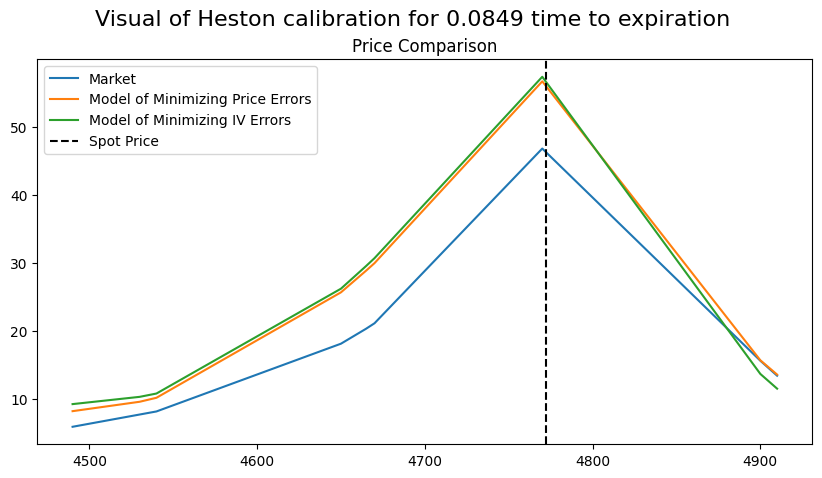

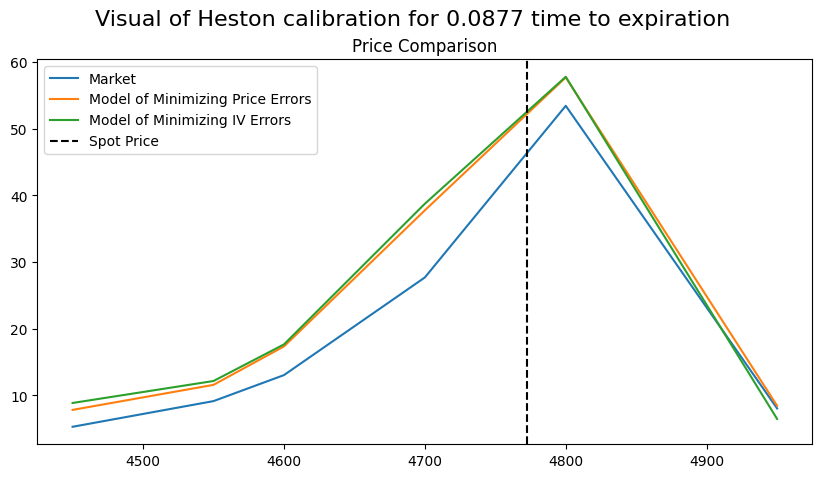

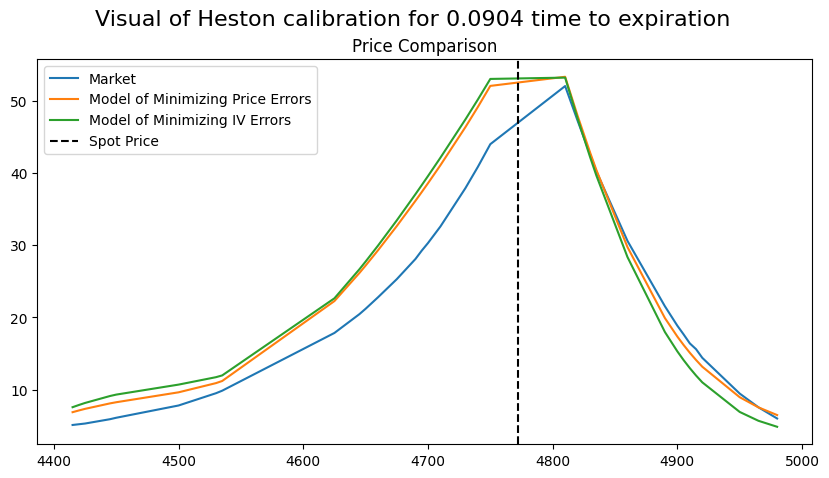

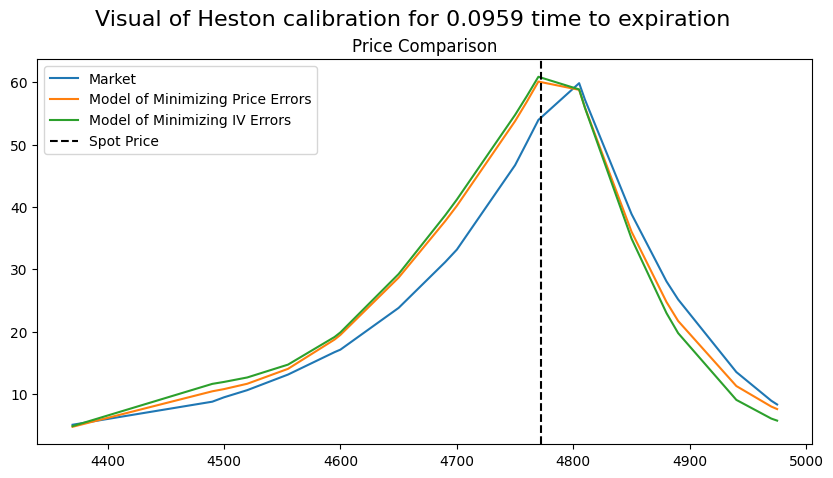

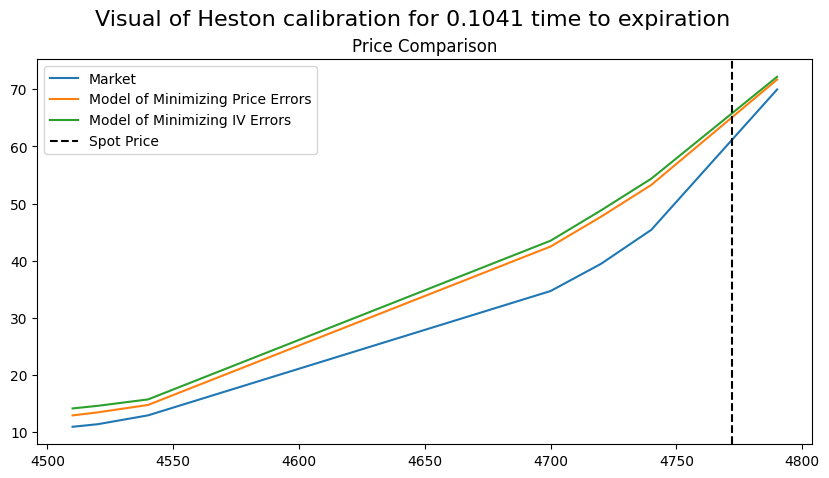

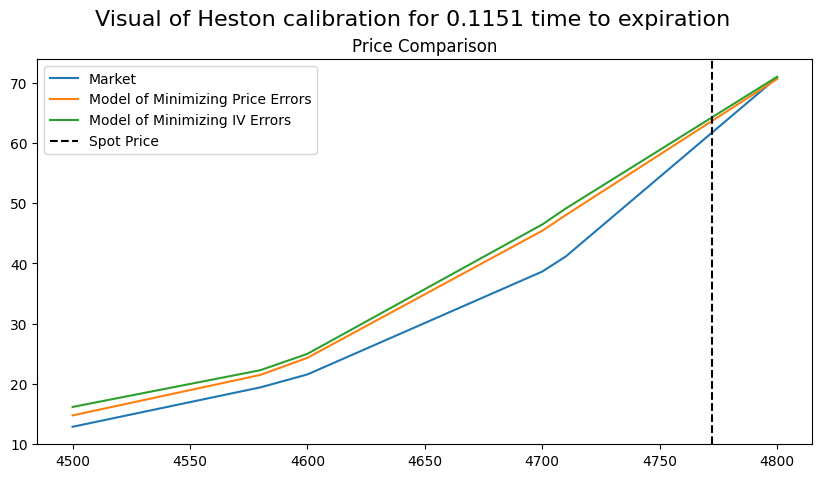

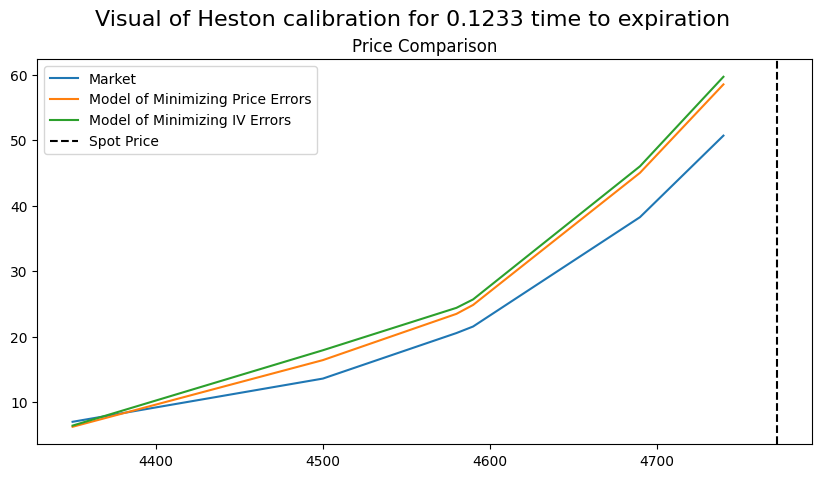

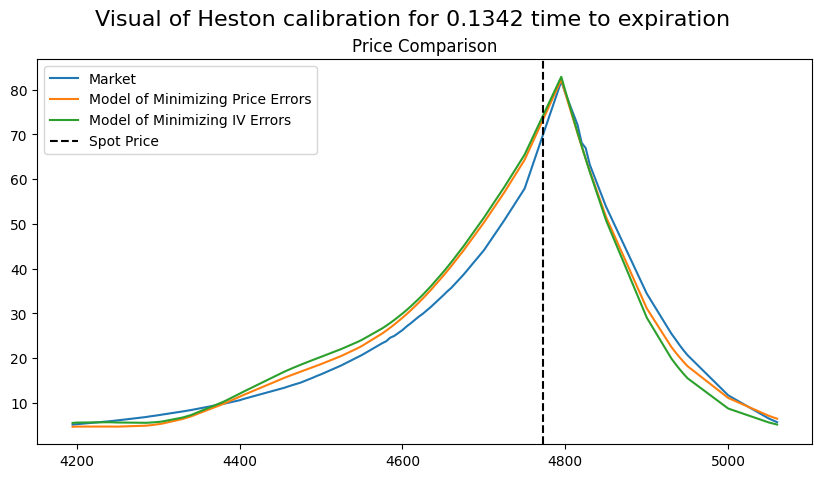

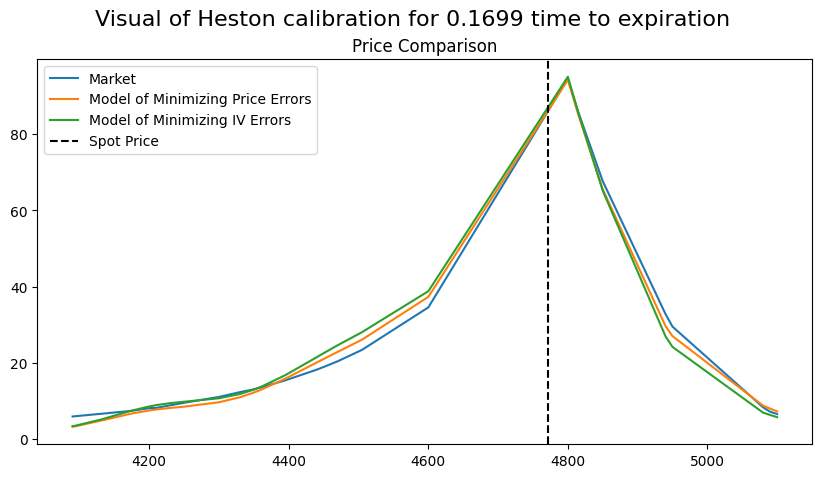

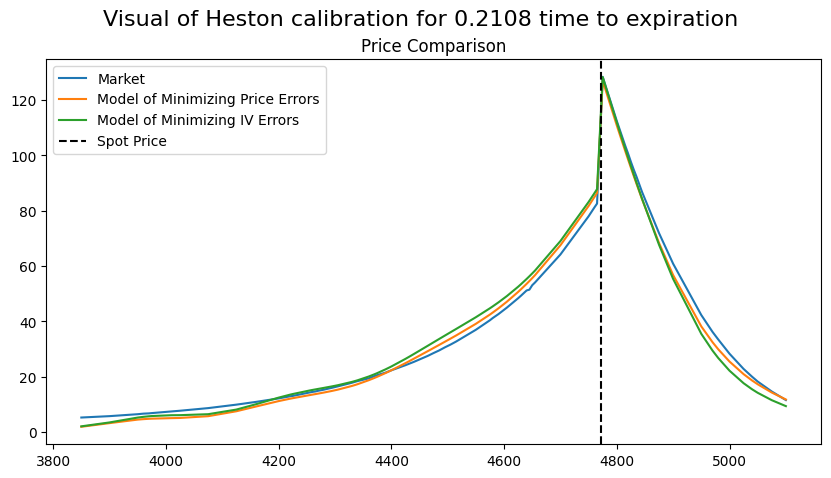

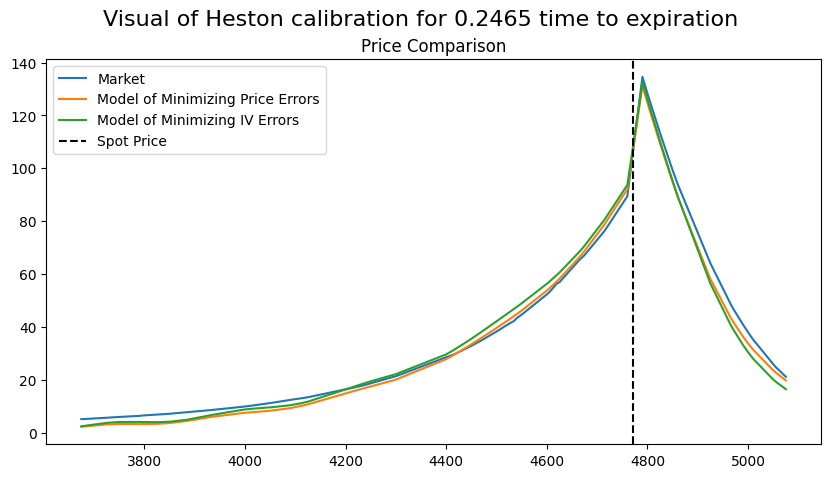

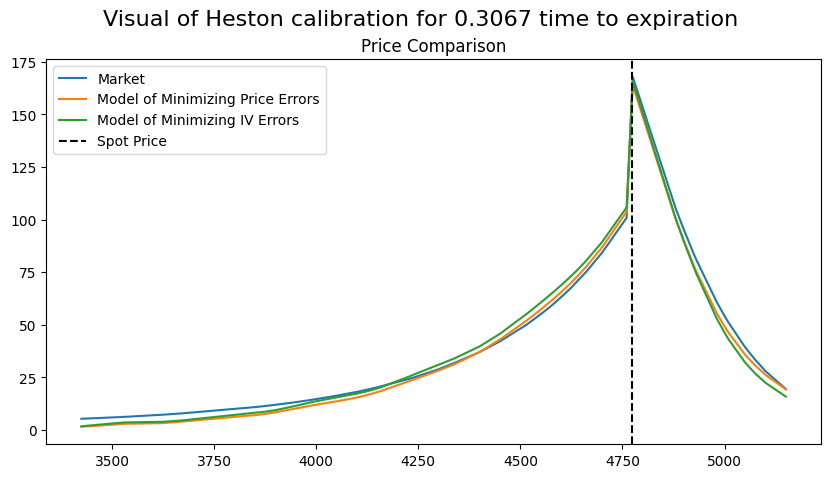

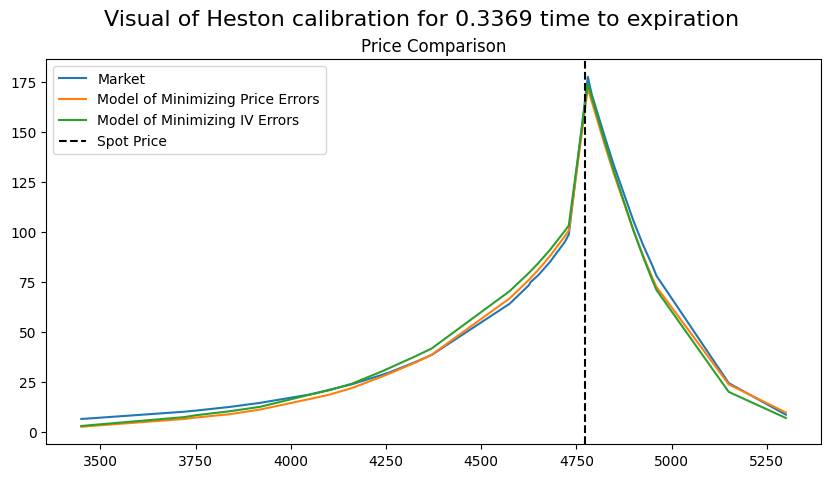

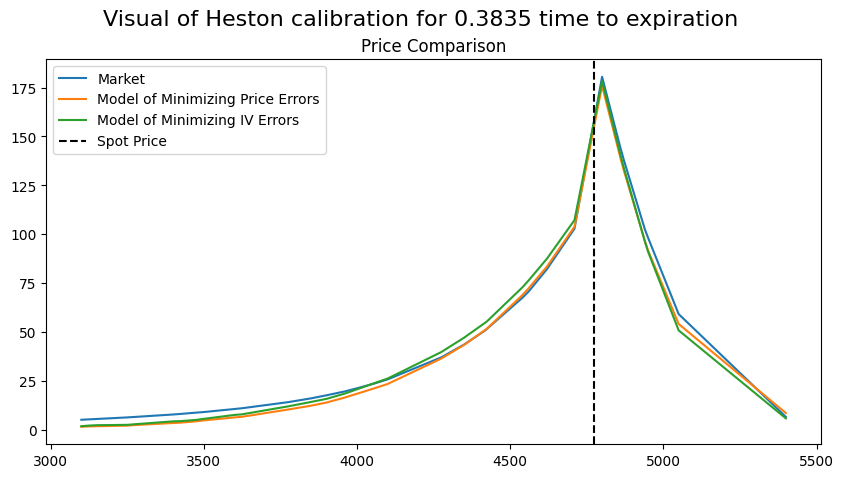

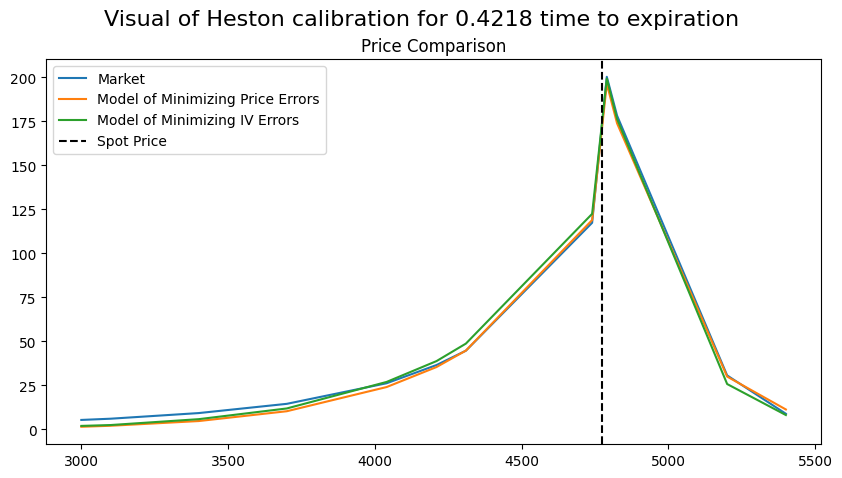

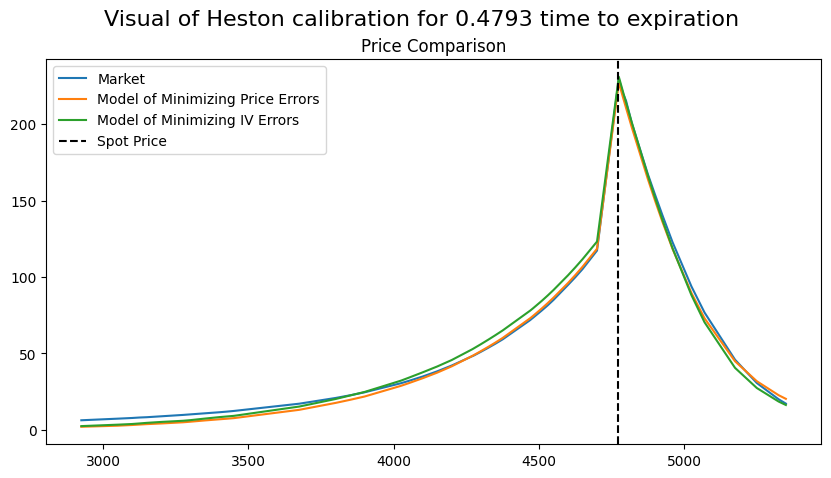

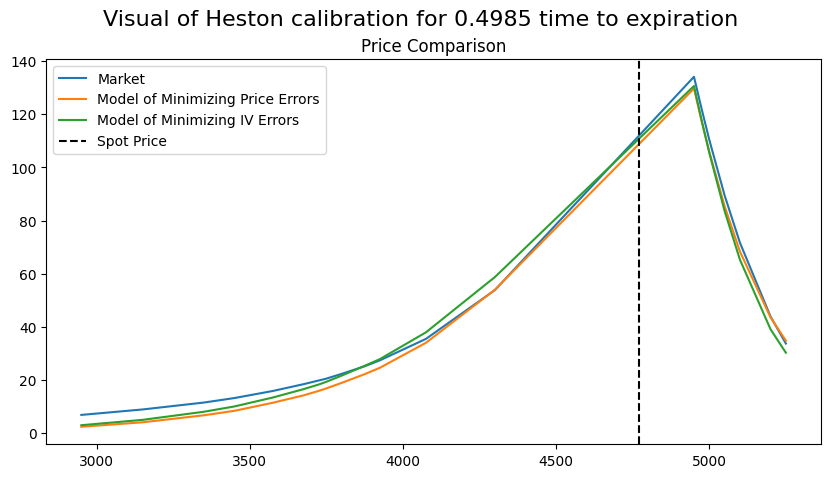

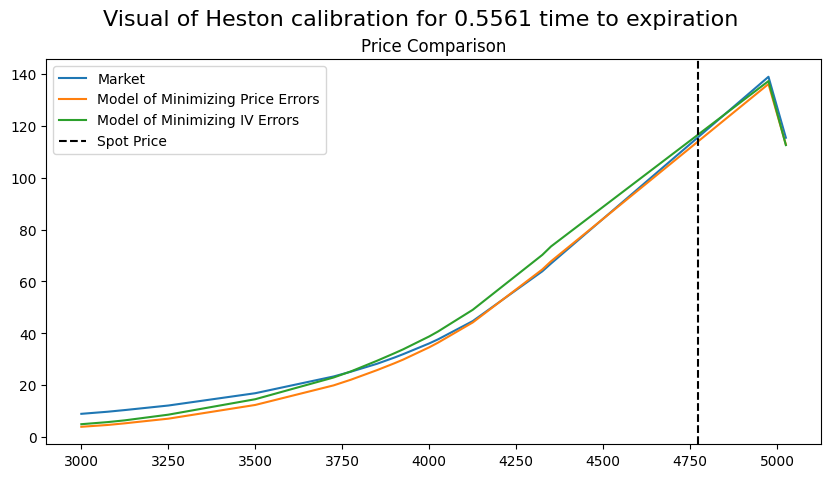

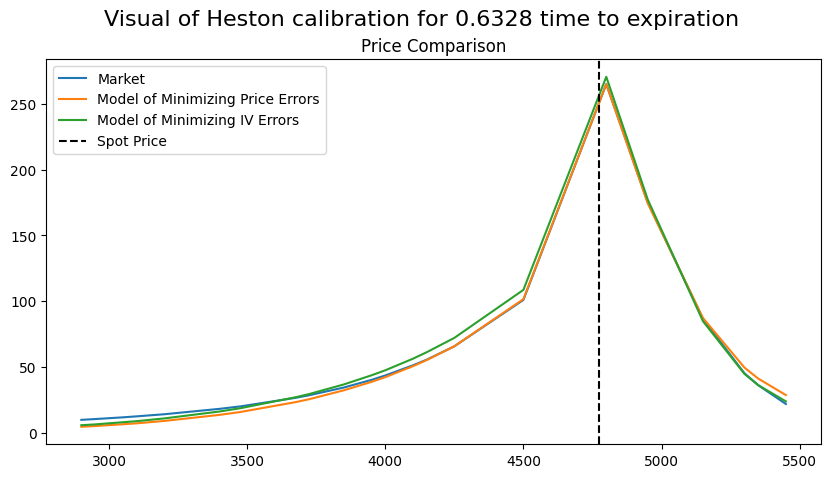

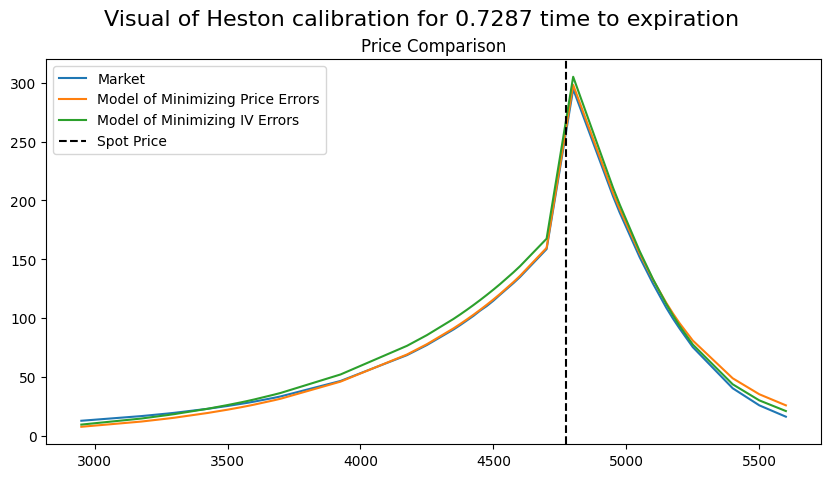

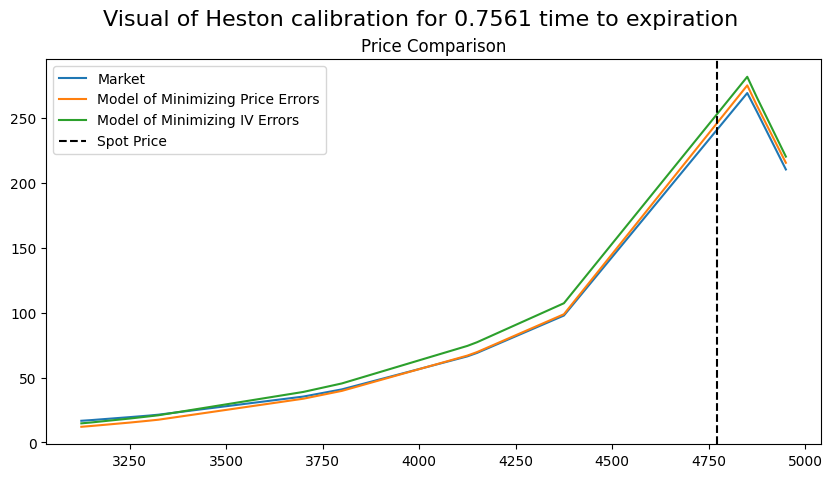

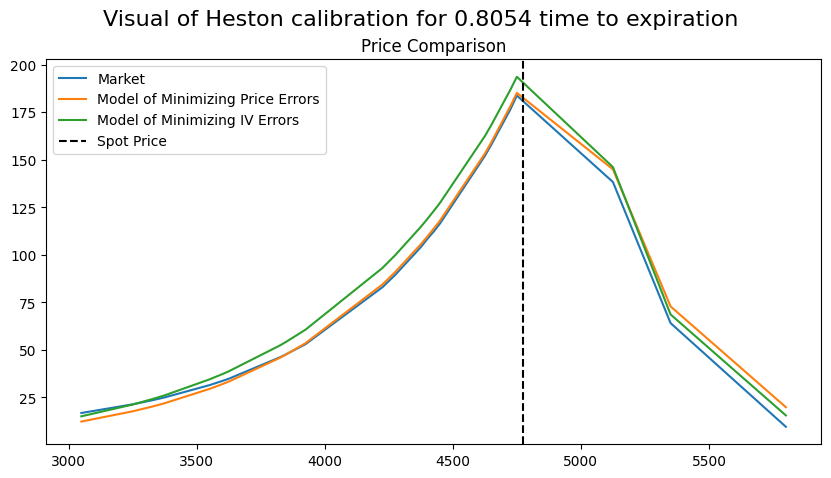

In [155]:
# ============================================================
# Visuals od heston data fitting
# ============================================================

v0_price, kappa_price, theta_price, xi_price, rho_price = result_price.x

v0_iv, kappa_iv, theta_iv, xi_iv, rho_iv = result_iv.x

for t in np.unique(X['tau'].values):
    Y = X[X['tau'] == t].copy()
    if len(Y) <= 3:
        continue

    market_prices = Y['mid'].values
    market_ivs = Y['iv'].values
    strikes = Y['strike'].values
    option_types = Y['type'].values

    # For CALL and PUT options
    price_model_prices = heston_price_vectorized(S0,strikes,t*np.ones(len(strikes)),v0_price,r,kappa_price,theta_price,xi_price,rho_price, option_types)
    price_model_ivs = bs_iv_vectorized(S0*np.ones(len(strikes)), strikes, t*np.ones(len(strikes)), r, price_model_prices, option_types)
    iv_model_prices = heston_price_vectorized(S0,strikes,t*np.ones(len(strikes)),v0_iv,r,kappa_iv,theta_iv,xi_iv,rho_iv, option_types)
    iv_model_ivs = bs_iv_vectorized(S0*np.ones(len(strikes)),strikes,t*np.ones(len(strikes)),r,iv_model_prices, option_types)

    # For CALL options only
    # price_model_prices = heston_call_vectorized(S0,strikes,t*np.ones(len(strikes)),v0_price,r,kappa_price,theta_price,xi_price,rho_price)
    # price_model_ivs = bs_call_iv_vectorized(S0*np.ones(len(strikes)),strikes,t*np.ones(len(strikes)),r,price_model_prices)
    # iv_model_prices = heston_call_vectorized(S0,strikes,t*np.ones(len(strikes)),v0_iv,r,kappa_iv,theta_iv,xi_price,rho_iv)
    # iv_model_ivs = bs_call_iv_vectorized(S0*np.ones(len(strikes)),strikes,t*np.ones(len(strikes)),r,iv_model_prices)

    fig,ax = plt.subplots(1,1,figsize = (10,5))

    ax.plot(strikes, market_prices, label = 'Market')
    ax.plot(strikes, price_model_prices, label = 'Model of Minimizing Price Errors')
    ax.plot(strikes, iv_model_prices, label = 'Model of Minimizing IV Errors')
    ax.axvline(S0,ls = '--', color = 'black', label = 'Spot Price')
    ax.set_title('Price Comparison')
    ax.legend()

    # fig,ax = plt.subplots(1,2,figsize = (10,5))

    # ax[0].plot(strikes, market_prices, label = 'Market')
    # ax[0].plot(strikes, price_model_prices, label = 'Model of Minimizing Price Errors')
    # ax[0].plot(strikes, iv_model_prices, label = 'Model of Minimizing IV Errors')
    # ax[0].axvline(S0,ls = '--', color = 'black', label = 'Spot Price')
    # ax[0].set_title('Price Comparison')
    # ax[0].legend()

    # ax[1].plot(strikes,market_ivs, label = 'Market')
    # ax[1].plot(strikes,price_model_ivs, label = 'Model of Minimizing Price Errors')
    # ax[1].plot(strikes,iv_model_ivs, label = 'Model of Minimizing IV Errors')
    # ax[1].axvline(S0,ls = '--', color = 'black', label = 'Spot Price')
    # ax[1].set_title('IV Comparison')
    # ax[1].legend()

    plt.suptitle(f'Visual of Heston calibration for {t:.4f} time to expiration', size = 16)
    plt.show()
    

In [156]:
# ============================================================
# 3D IV surface: market IV and Heston IV on train data
# ============================================================

surface_df = train.copy()

x = surface_df["tau"].to_numpy(float)
y = surface_df["strike"].to_numpy(float)
z = surface_df["iv"].to_numpy(float)
z_heston = surface_df["heston_iv"].to_numpy(float)

# Grid
tau_grid = np.linspace(x.min(), x.max(), 60)
strike_grid = np.linspace(y.min(), y.max(), 80)
tau_mesh, strike_mesh = np.meshgrid(tau_grid, strike_grid)

market_IV_grid = griddata(points=(x, y), values=z, xi=(tau_mesh, strike_mesh), method="linear")
heston_IV_grid = griddata(points=(x, y), values=z_heston, xi=(tau_mesh, strike_mesh), method="linear")

fig = go.Figure()
fig.add_trace(go.Surface(
    x=tau_mesh, y=strike_mesh, z=market_IV_grid,
    colorscale="Viridis", opacity=0.4))
fig.add_trace(go.Scatter3d(
    x=surface_df["tau"], y=surface_df["strike"], z=surface_df["iv"],
    mode="markers", name="Market IV", marker=dict(size=3, opacity=0.7)))
fig.add_trace(go.Scatter3d(
    x=surface_df["tau"], y=surface_df["strike"], z=surface_df["heston_iv"],
    mode="markers", name="Heston IV", marker=dict(size=3, opacity=0.7)))
fig.add_trace(go.Surface(
    x=tau_mesh, y=strike_mesh, z=heston_IV_grid,
    colorscale="Cividis", opacity=0.4))
fig.update_layout(
    title="Market IV vs Heston IV Surface (Train set)",
    scene=dict(xaxis_title="Time to maturity", yaxis_title="Strike", zaxis_title="Implied volatility"),
    width=900, height=700)
fig.show()

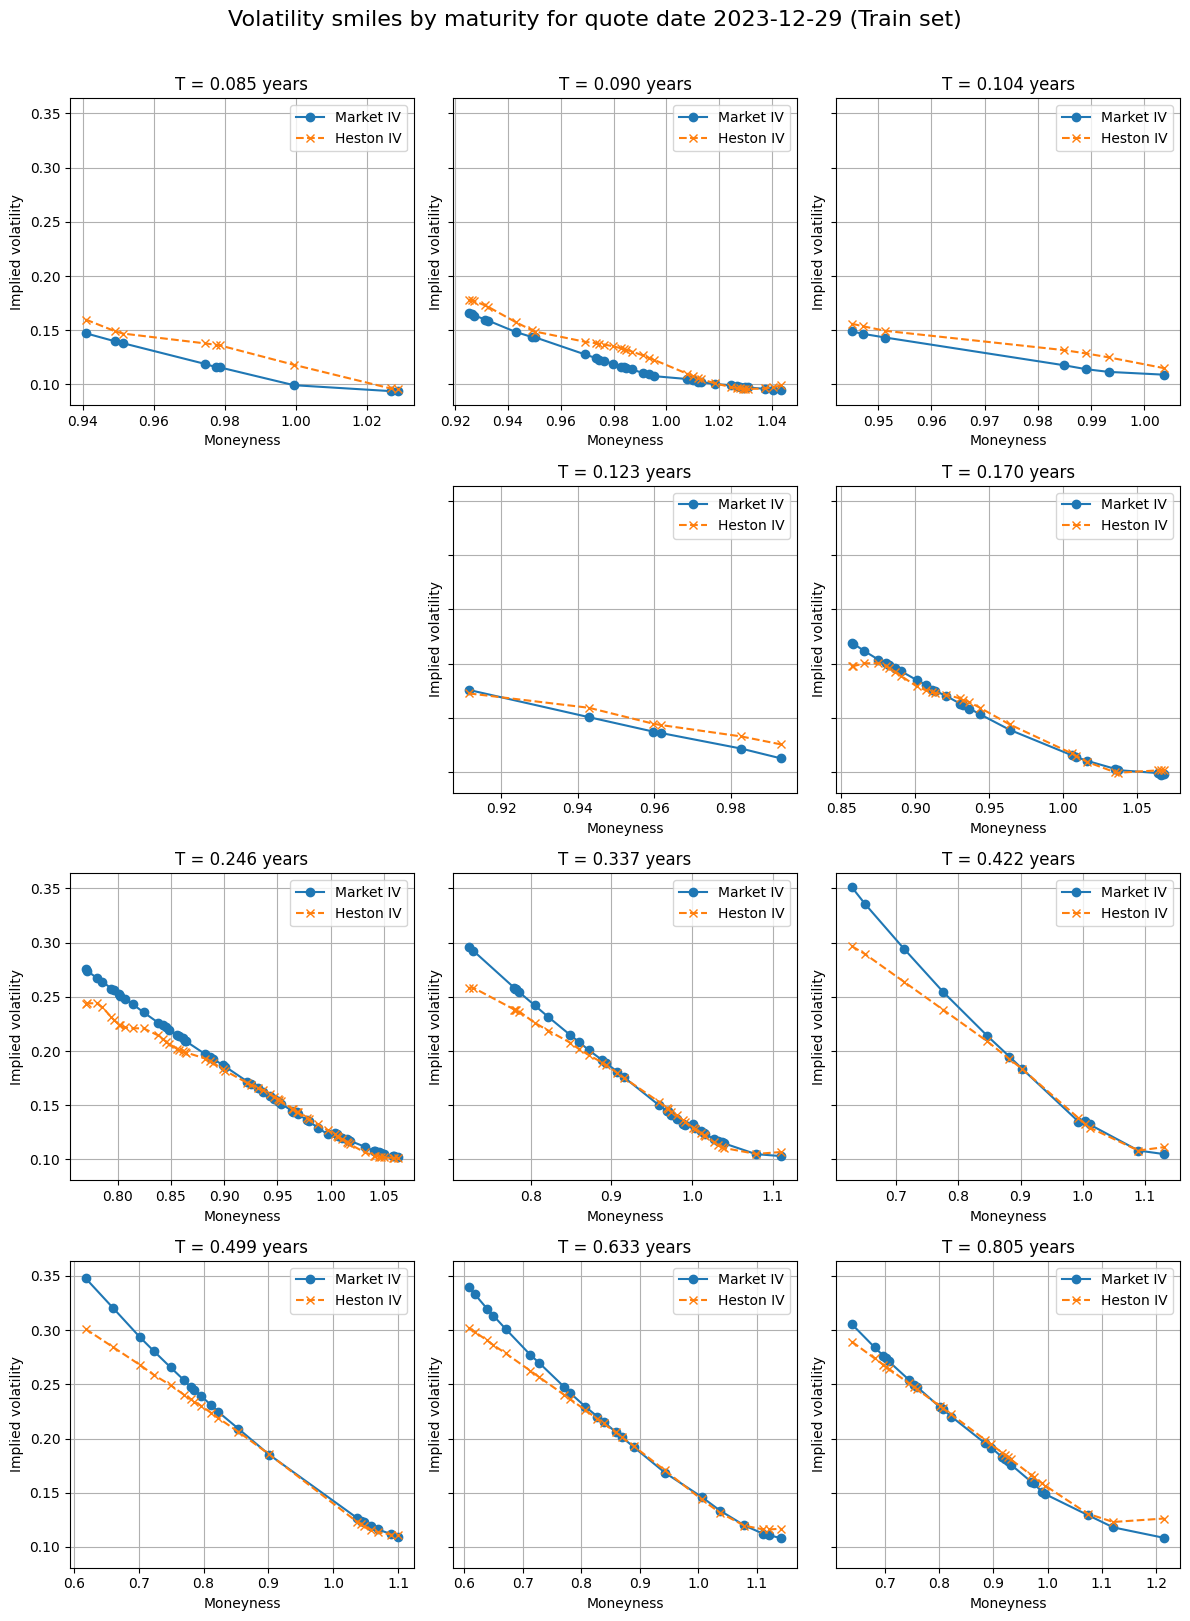

In [157]:
# ============================================================
# 2D volatility smiles by maturity (moneyness axis)
# ============================================================

smile_df = train.copy()
smile_df["tau_bucket"] = smile_df["tau"].round(3)
available_taus = np.sort(smile_df["tau_bucket"].unique())
n_smiles = min(12, len(available_taus))
selected_taus = available_taus[np.linspace(0, len(available_taus) - 1, n_smiles).astype(int)]

n_smiles = len(selected_taus)
n_cols = 3
n_rows = int(np.ceil(n_smiles / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 4 * n_rows), sharey=True)
fig.suptitle(f"Volatility smiles by maturity for quote date {QUOTE_DATE} (Train set)", fontsize=16, y=1.01)
axes = np.array(axes).reshape(-1)

for ax, tau_i in zip(axes, selected_taus):
    sub = smile_df[smile_df["tau_bucket"] == tau_i].sort_values("moneyness")
    if len(sub) < 3:
        ax.set_visible(False)
        continue
    ax.plot(sub["moneyness"], sub["iv"], marker="o", linestyle="-", label="Market IV")
    ax.plot(sub["moneyness"], sub["heston_iv"], marker="x", linestyle="--", label="Heston IV")
    ax.set_title(f"T = {tau_i:.3f} years")
    ax.set_xlabel("Moneyness")
    ax.set_ylabel("Implied volatility")
    ax.grid(True)
    ax.legend()

for j in range(len(selected_taus), len(axes)):
    axes[j].set_visible(False) 

plt.tight_layout()
plt.show()

### TEST: Application of calibrated params of Heston model on test data

In [158]:
# ============================================================
# Using calibrated parameters of Heston model on train data, apply to test data
# ============================================================

qd = QUOTE_DATE
X = test[test['quote_date']==qd].copy()
print(X.shape)
strikes = X['strike'].values
market_prices = X['mid'].values
ttes = X['tau'].values
market_ivs = X['iv'].values
S0 = X['underlying_last'].iloc[0]
spots = X['underlying_last'].values
option_types = X['type'].values  

# Calibrated parameters of Heston model on train data
v0, kappa, theta, xi, rho = result_price.x 

# For CALL and PUT options
test['heston_price'] = heston_price_vectorized(S0, strikes, ttes, v0, r, kappa, theta, xi, rho, option_types)
test["price_error"] = test["heston_price"] - test["mid"]

# test['heston_iv'] = bs_iv_vectorized(spots, strikes, ttes, r, market_prices, option_types)
test['heston_iv'] = bs_iv_vectorized(spots, strikes, ttes, r, test['heston_price'].to_numpy(float), option_types)
test['iv_error'] = test['iv'] - test['heston_iv']

# For CALL options
# test['heston_price'] = heston_call_vectorized(S0, strikes, ttes, v0, r, kappa, theta, xi, rho)
# test["price_error"] = test["heston_price"] - test["mid"]

# test['heston_iv'] = bs_call_iv_vectorized(spots, strikes, ttes, r, market_prices)
# test['iv_error'] = test['iv'] - test['heston_iv']

price_rmse = np.sqrt(np.mean(test["price_error"] ** 2))
price_mae = np.mean(np.abs(test["price_error"]))

iv_rmse = np.sqrt(np.mean(test["iv_error"] ** 2))
iv_mae = np.mean(np.abs(test["iv_error"]))

print("Test price diagnostics")
print("---------------------------")
print(f"Price RMSE: {price_rmse:.6f}")
print(f"Price MAE:  {price_mae:.6f}")
print()
print("Test IV diagnostics")
print("----------------------------------------")
print(f"IV RMSE: {iv_rmse:.6f}")
print(f"IV MAE:  {iv_mae:.6f}")

(186, 20)
Test price diagnostics
---------------------------
Price RMSE: 3.269422
Price MAE:  2.728340

Test IV diagnostics
----------------------------------------
IV RMSE: 0.012558
IV MAE:  0.007812


### TEST: Plots, 3d surface, 2d smiles

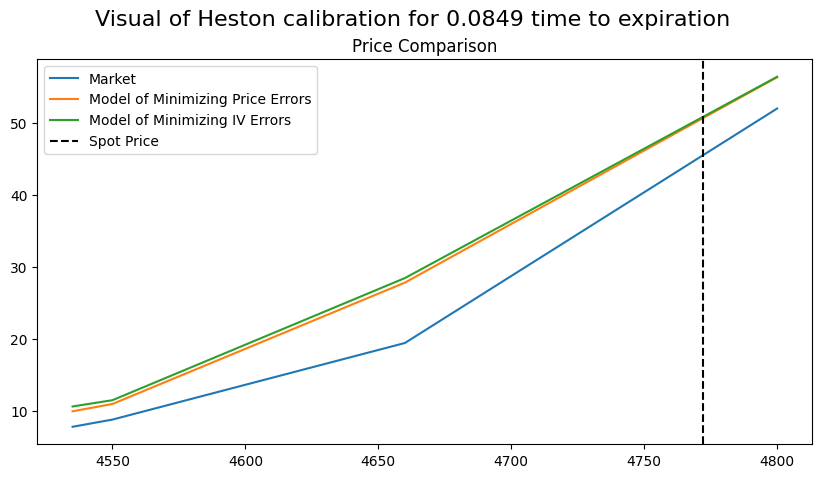

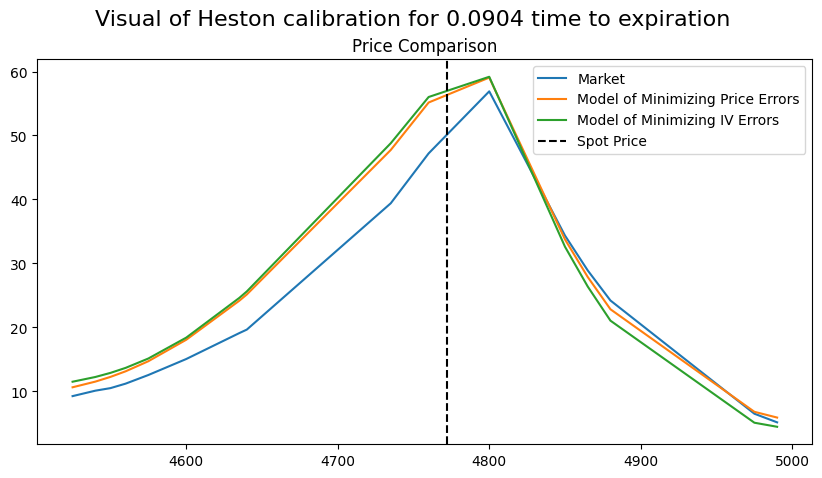

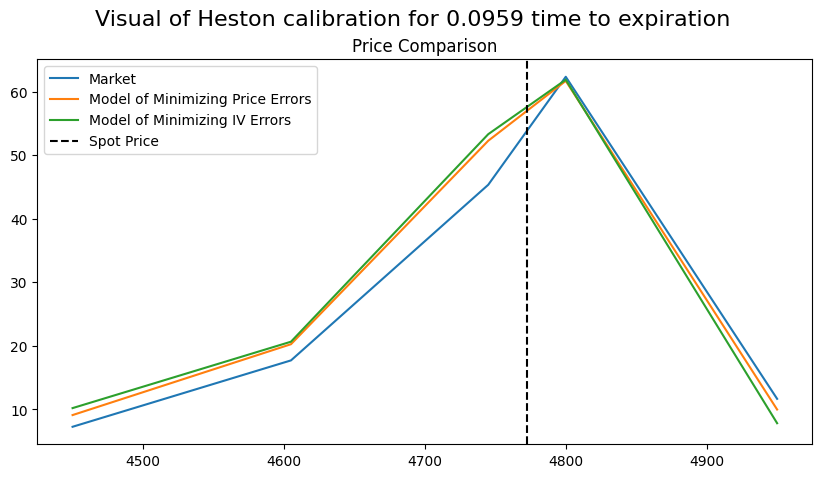

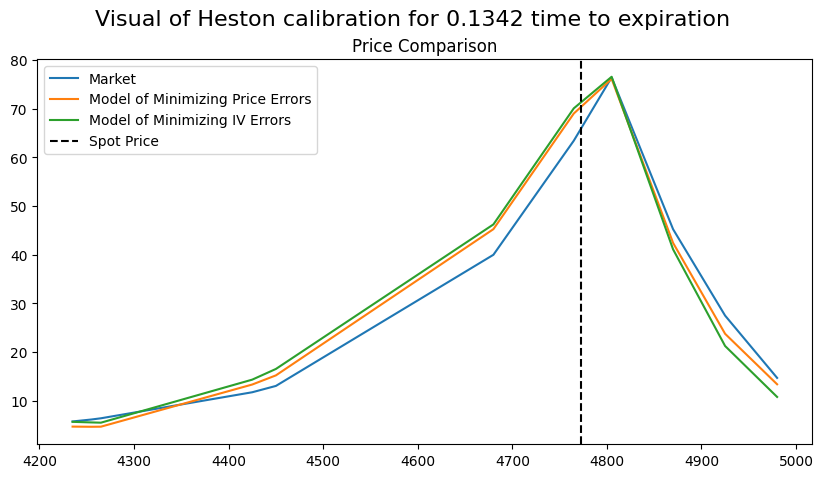

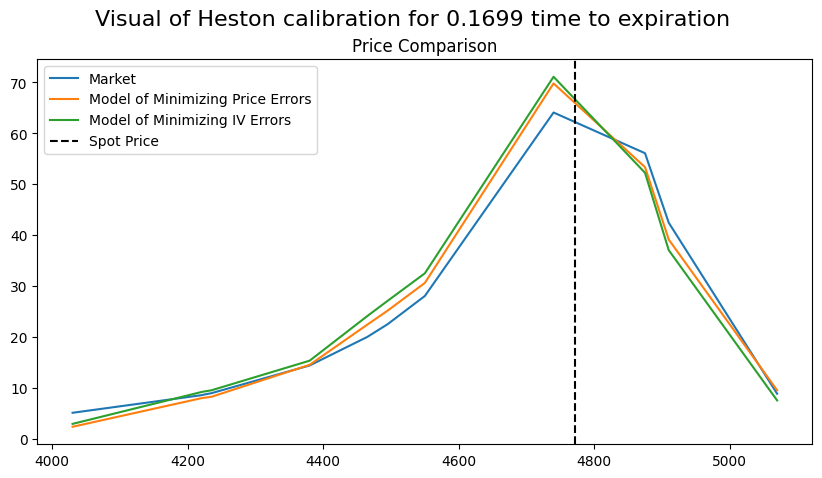

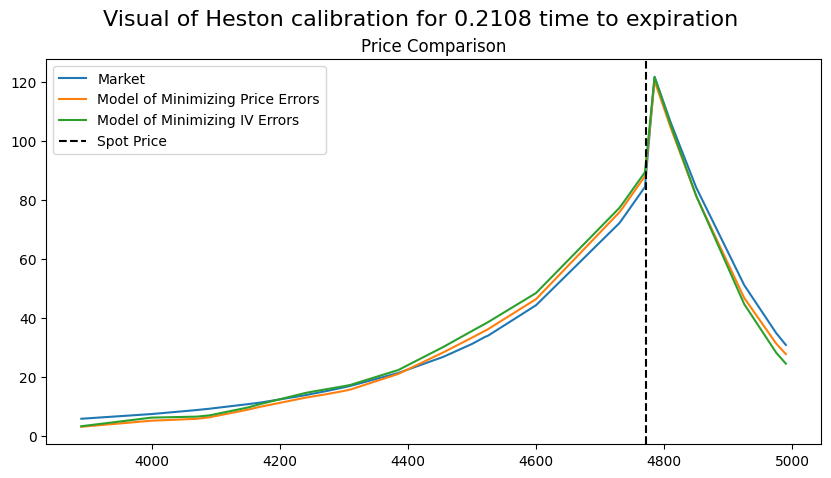

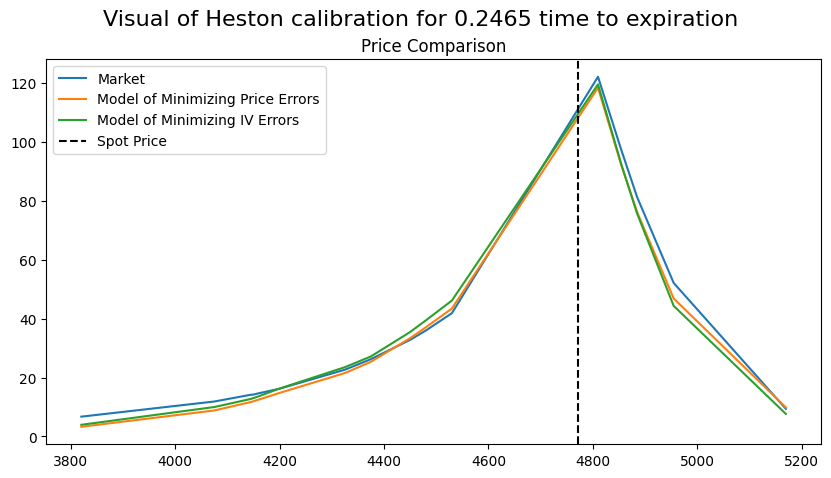

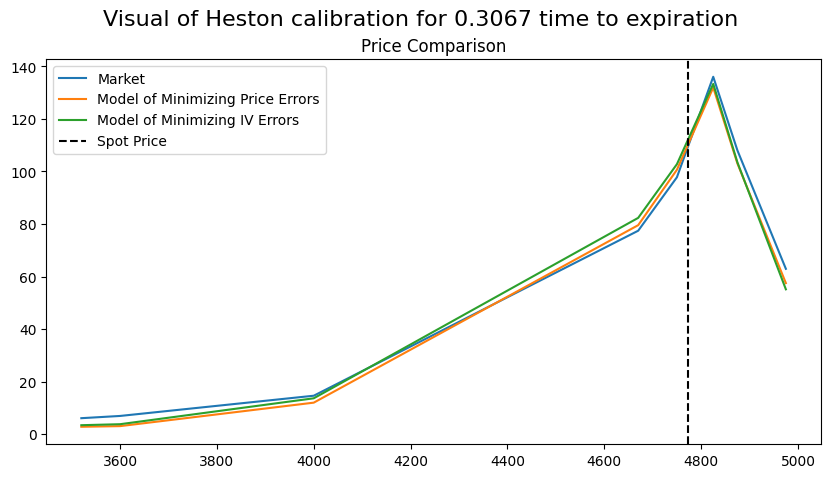

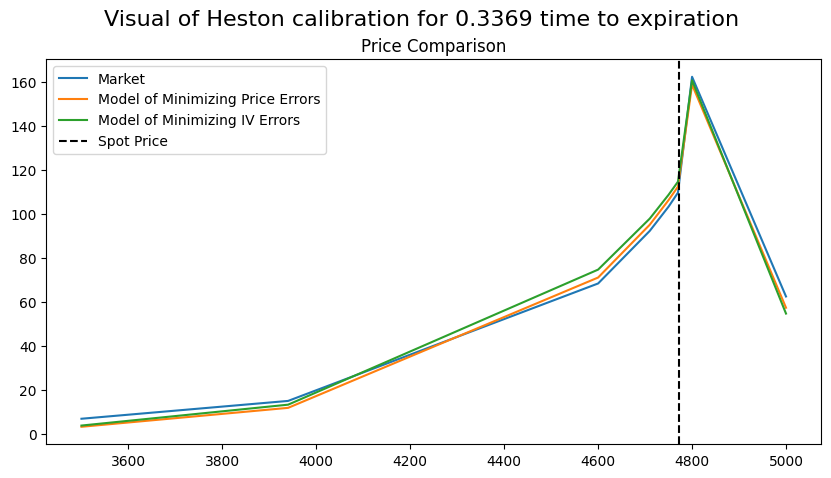

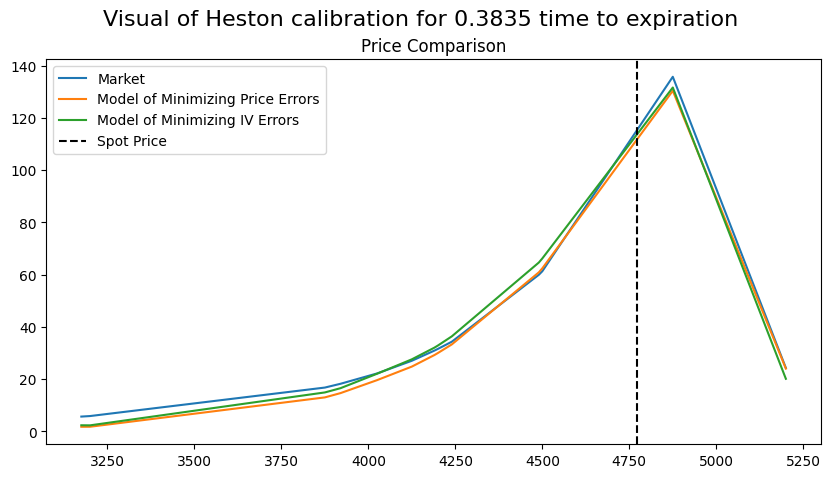

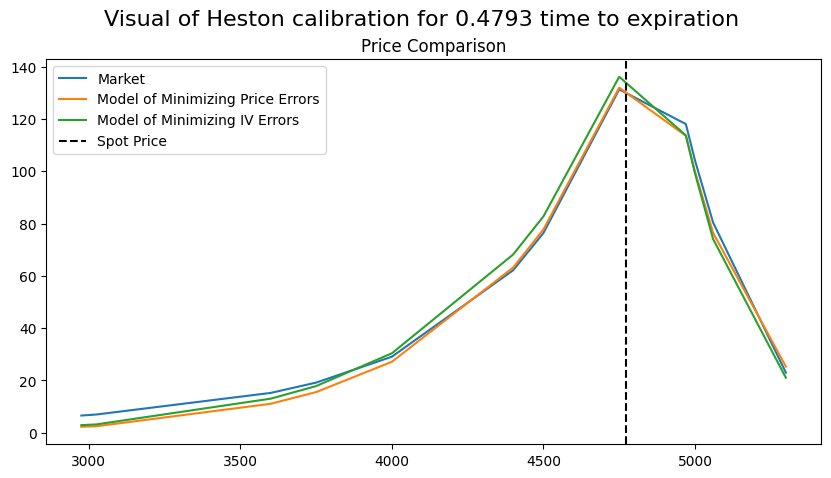

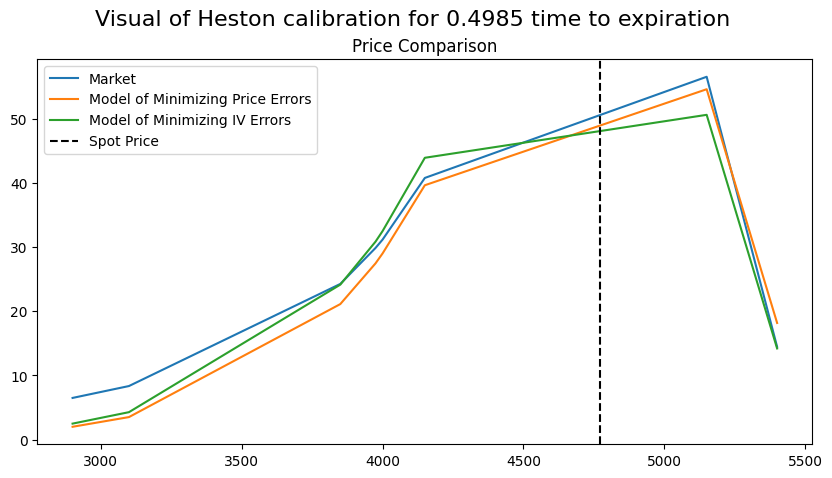

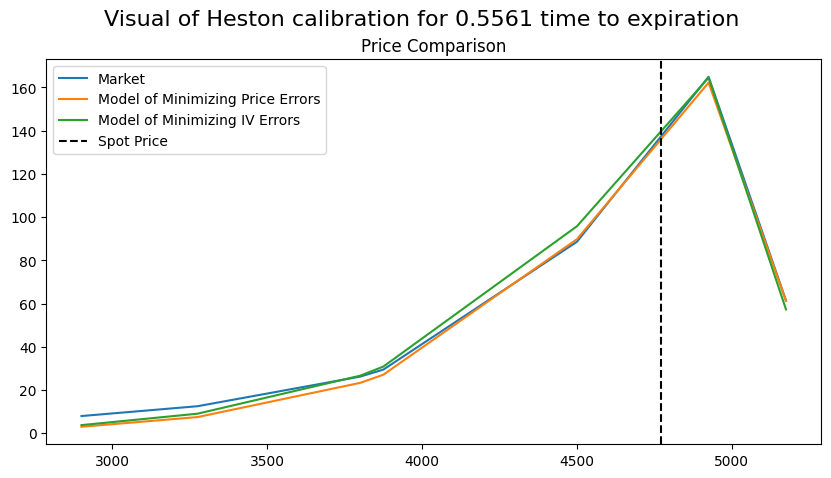

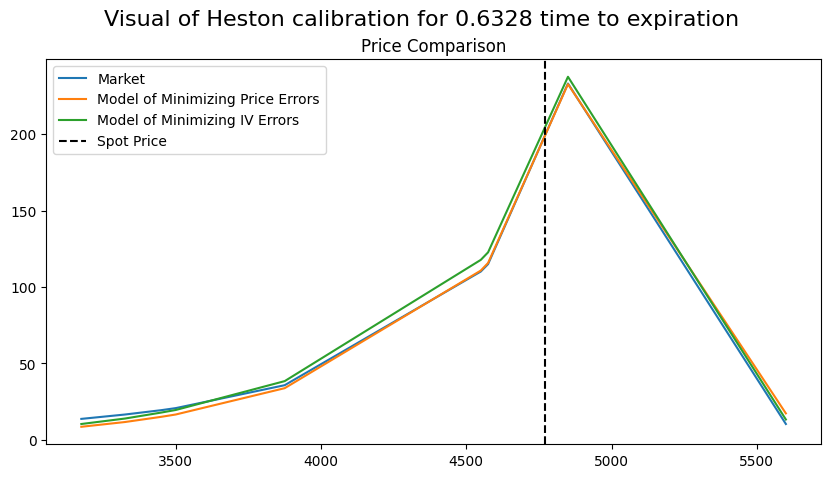

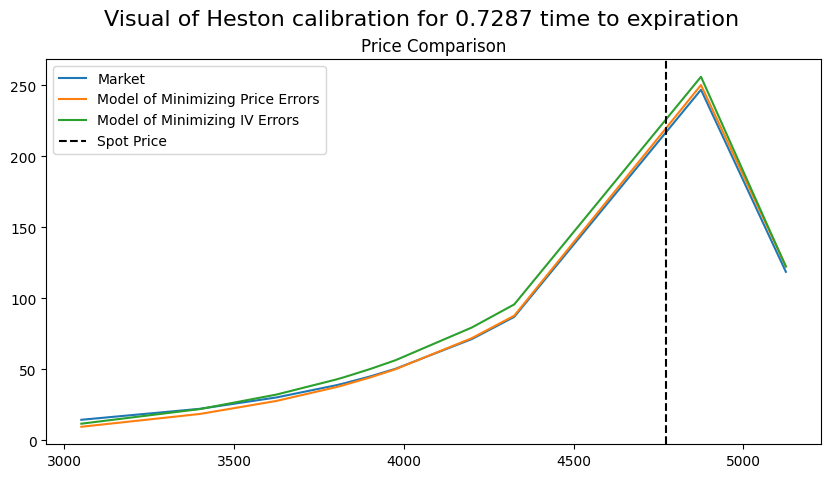

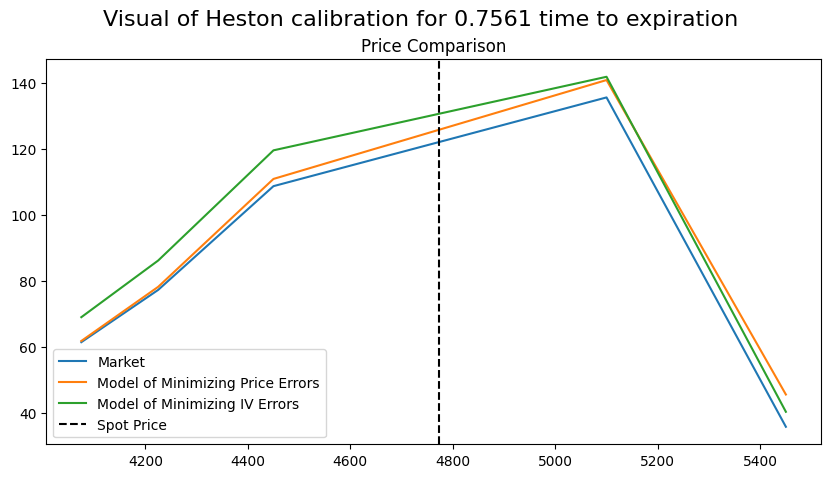

In [159]:
# ============================================================
# Visuals od heston data fitting
# ============================================================

v0_price, kappa_price, theta_price, xi_price, rho_price = result_price.x

v0_iv, kappa_iv, theta_iv, xi_iv, rho_iv = result_iv.x

for t in np.unique(X['tau'].values):
    Y = X[X['tau'] == t].copy()
    if len(Y) <= 3:
        continue

    market_prices = Y['mid'].values
    market_ivs = Y['iv'].values
    strikes = Y['strike'].values
    option_types = Y['type'].values

    # For CALL and PUT options
    price_model_prices = heston_price_vectorized(S0,strikes,t*np.ones(len(strikes)),v0_price,r,kappa_price,theta_price,xi_price,rho_price, option_types)
    price_model_ivs = bs_iv_vectorized(S0*np.ones(len(strikes)), strikes, t*np.ones(len(strikes)), r, price_model_prices, option_types)
    iv_model_prices = heston_price_vectorized(S0,strikes,t*np.ones(len(strikes)),v0_iv,r,kappa_iv,theta_iv,xi_iv,rho_iv, option_types)
    iv_model_ivs = bs_iv_vectorized(S0*np.ones(len(strikes)),strikes,t*np.ones(len(strikes)),r,iv_model_prices, option_types)

    # For CALL options only
    # price_model_prices = heston_call_vectorized(S0,strikes,t*np.ones(len(strikes)),v0_price,r,kappa_price,theta_price,xi_price,rho_price)
    # price_model_ivs = bs_call_iv_vectorized(S0*np.ones(len(strikes)),strikes,t*np.ones(len(strikes)),r,price_model_prices)
    # iv_model_prices = heston_call_vectorized(S0,strikes,t*np.ones(len(strikes)),v0_iv,r,kappa_iv,theta_iv,xi_price,rho_iv)
    # iv_model_ivs = bs_call_iv_vectorized(S0*np.ones(len(strikes)),strikes,t*np.ones(len(strikes)),r,iv_model_prices)


    fig,ax = plt.subplots(1,1,figsize = (10,5))

    ax.plot(strikes, market_prices, label = 'Market')
    ax.plot(strikes, price_model_prices, label = 'Model of Minimizing Price Errors')
    ax.plot(strikes, iv_model_prices, label = 'Model of Minimizing IV Errors')
    ax.axvline(S0,ls = '--', color = 'black', label = 'Spot Price')
    ax.set_title('Price Comparison')
    ax.legend()

    # fig,ax = plt.subplots(1,2,figsize = (10,5))

    # ax[0].plot(strikes, market_prices, label = 'Market')
    # ax[0].plot(strikes, price_model_prices, label = 'Model of Minimizing Price Errors')
    # ax[0].plot(strikes, iv_model_prices, label = 'Model of Minimizing IV Errors')
    # ax[0].axvline(S0,ls = '--', color = 'black', label = 'Spot Price')
    # ax[0].set_title('Price Comparison')
    # ax[0].legend()

    # ax[1].plot(strikes,market_ivs, label = 'Market')
    # ax[1].plot(strikes,price_model_ivs, label = 'Model of Minimizing Price Errors')
    # ax[1].plot(strikes,iv_model_ivs, label = 'Model of Minimizing IV Errors')
    # ax[1].axvline(S0,ls = '--', color = 'black', label = 'Spot Price')
    # ax[1].set_title('IV Comparison')
    # ax[1].legend()

    plt.suptitle(f'Visual of Heston calibration for {t:.4f} time to expiration', size = 16)
    plt.show()
    

In [160]:
# ============================================================
# 3D IV surface: market IV and Heston IV on train data
# ============================================================

surface_df = test.copy()

x = surface_df["tau"].to_numpy(float)
y = surface_df["strike"].to_numpy(float)
z = surface_df["iv"].to_numpy(float)
z_heston = surface_df["heston_iv"].to_numpy(float)

# Grid
tau_grid = np.linspace(x.min(), x.max(), 60)
strike_grid = np.linspace(y.min(), y.max(), 80)
tau_mesh, strike_mesh = np.meshgrid(tau_grid, strike_grid)

market_IV_grid = griddata(points=(x, y), values=z, xi=(tau_mesh, strike_mesh), method="linear")
heston_IV_grid = griddata(points=(x, y), values=z_heston, xi=(tau_mesh, strike_mesh), method="linear")

fig = go.Figure()
fig.add_trace(go.Surface(
    x=tau_mesh, y=strike_mesh, z=market_IV_grid,
    colorscale="Viridis", opacity=0.4))
fig.add_trace(go.Scatter3d(
    x=surface_df["tau"], y=surface_df["strike"], z=surface_df["iv"],
    mode="markers", name="Market IV", marker=dict(size=3, opacity=0.7)))
fig.add_trace(go.Scatter3d(
    x=surface_df["tau"], y=surface_df["strike"], z=surface_df["heston_iv"],
    mode="markers", name="Heston IV", marker=dict(size=3, opacity=0.7)))
fig.add_trace(go.Surface(
    x=tau_mesh, y=strike_mesh, z=heston_IV_grid,
    colorscale="Cividis", opacity=0.4))
fig.update_layout(
    title="Market IV vs Heston IV Surface (Test set)",
    scene=dict(xaxis_title="Time to maturity", yaxis_title="Strike", zaxis_title="Implied volatility"),
    width=900, height=700)
fig.show()

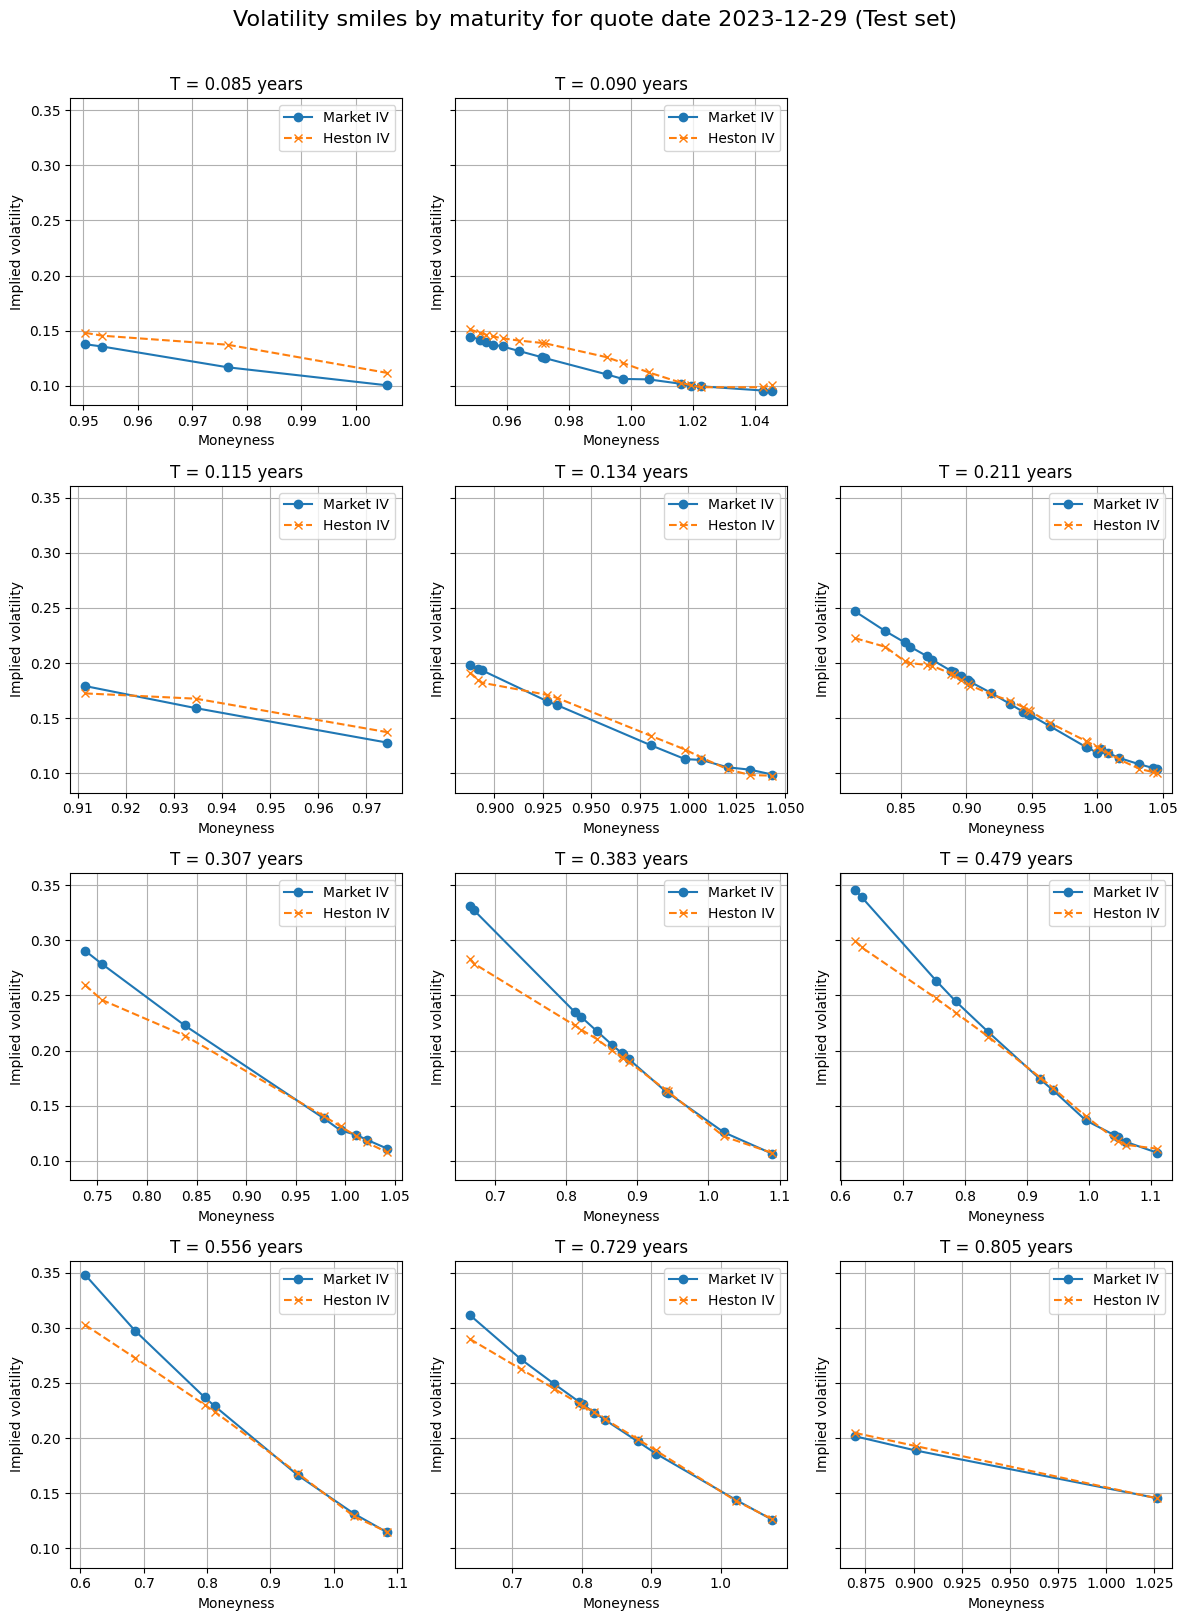

In [161]:
# ============================================================
# 2D volatility smiles by maturity (moneyness axis)
# ============================================================

smile_df = test.copy()
smile_df["tau_bucket"] = smile_df["tau"].round(3)
available_taus = np.sort(smile_df["tau_bucket"].unique())
n_smiles = min(12, len(available_taus))
selected_taus = available_taus[np.linspace(0, len(available_taus) - 1, n_smiles).astype(int)]

n_smiles = len(selected_taus)
n_cols = 3
n_rows = int(np.ceil(n_smiles / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 4 * n_rows), sharey=True)
fig.suptitle(f"Volatility smiles by maturity for quote date {QUOTE_DATE} (Test set)", fontsize=16, y=1.01)
axes = np.array(axes).reshape(-1)

for ax, tau_i in zip(axes, selected_taus):
    sub = smile_df[smile_df["tau_bucket"] == tau_i].sort_values("moneyness")
    if len(sub) < 3:
        ax.set_visible(False)
        continue
    ax.plot(sub["moneyness"], sub["iv"], marker="o", linestyle="-", label="Market IV")
    ax.plot(sub["moneyness"], sub["heston_iv"], marker="x", linestyle="--", label="Heston IV")
    ax.set_title(f"T = {tau_i:.3f} years")
    ax.set_xlabel("Moneyness")
    ax.set_ylabel("Implied volatility")
    ax.grid(True)
    ax.legend()

for j in range(len(selected_taus), len(axes)):
    axes[j].set_visible(False) 

plt.tight_layout()
plt.show()

### Arbitrage check plots

A European-style implied volatility smile is free of butterfly arbitrage iff the risk-neutral density stays non-negative, which — expressed on the total implied variance $w(k,\tau)=\tau,\sigma_{BS}(k,\tau)^2$ as a function of log-forward-moneyness $k=\ln(K/F)$ — is equivalent (Gatheral & Jacquier, 2014) to the diagnostic

$$
g(k) = \left(1 - \frac{k,w'(k)}{2w(k)}\right)^2 - \frac{w'(k)^2}{4}\left(\frac{1}{w(k)} + \frac14\right) + \frac{w''(k)}{2} ;\ge; 0 \quad \forall k
$$

where $w'$, $w''$ are the first and second derivatives of $w$ with respect to $k$, approximated below by central finite differences with step eps. Any $k$ with $g(k) < 0$ corresponds to a strike where the model-implied risk-neutral density would be negative — i.e. a butterfly spread priced below its intrinsic floor.

Maturity: 0.306740
Minimum g(k): -0.16962221
Number of negative points: 6
Fraction negative: 3.0000%


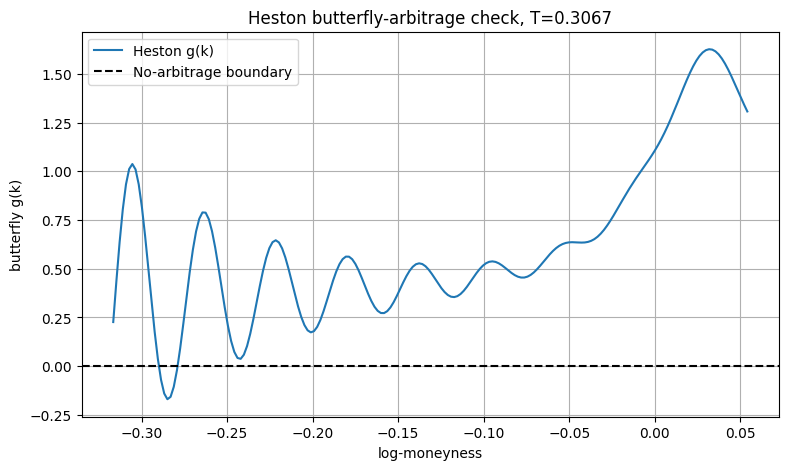

In [162]:
def g_of(predict_w, k, tau, eps=1e-3, w_floor=1e-12):
    """
    Gatheral-Jacquier butterfly-arbitrage diagnostic.

    Parameters
    ----------
    predict_w : callable
        Function predict_w(k, tau_array) returning total implied variance.
    k : array-like
        Log-forward moneyness, log(K / F).
    tau : float
        Time to maturity.
    eps : float
        Finite-difference step in log-moneyness.

    Returns
    -------
    g : np.ndarray
        Butterfly diagnostic. A negative value indicates butterfly arbitrage.
    """
    k = np.asarray(k, dtype=float)
    tau_array = np.full_like(k, tau, dtype=float)

    w = np.maximum(predict_w(k, tau_array), w_floor)

    w_plus = predict_w(k + eps, tau_array)
    w_minus = predict_w(k - eps, tau_array)

    wk = (w_plus - w_minus) / (2.0 * eps)
    wkk = (w_plus - 2.0 * w + w_minus) / eps**2

    g = (
        (1.0 - k * wk / (2.0 * w))**2
        - (wk**2 / 4.0) * (1.0 / w + 0.25)
        + 0.5 * wkk
    )

    return g


def make_heston_total_variance_predictor(
    S0,r,v0,kappa,theta,xi,rho,integration_limit=150,n_phi=2000,
):
    """
    Return a function w(k, tau) = tau * Heston_IV(k, tau)^2.
    """

    def predict_w(log_moneyness, ttes):
        log_moneyness = np.asarray(log_moneyness, dtype=float)
        ttes = np.asarray(ttes, dtype=float)

        # Heston pricer assumes q = 0.
        forwards = S0 * np.exp(r * ttes)
        strikes = forwards * np.exp(log_moneyness)

        call_prices = heston_call_vectorized(
            S0=S0,strikes=strikes,ttes=ttes,v0=v0,r=r,kappa=kappa,theta=theta,xi=xi,rho=rho,integration_limit=integration_limit,n_phi=n_phi,
        )

        implied_vols = bs_call_iv_vectorized(
            spots=np.full_like(strikes, S0),strikes=strikes,ttes=ttes,r=r,prices=call_prices,
            sigma_guess=np.sqrt(v0),
            non_converged_nan=True,
        )
        return ttes * implied_vols**2

    return predict_w

v0, kappa, theta, xi, rho = result_price.x

predict_heston_w = make_heston_total_variance_predictor(
    S0=S0,r=r,v0=v0,kappa=kappa,theta=theta,xi=xi,rho=rho,
)

day = test["quote_date"].max()
d0 = df[df["quote_date"] == day]
# exp = d0["expire_date"].value_counts().idxmax()
exp = d0['expire_date'].unique()[13] # choose date to be the same as Yvonne
sl = d0[d0["expire_date"] == exp]
tau_val = float(sl["tau"].iloc[0])
kline = np.linspace(sl["log_moneyness"].min(), sl["log_moneyness"].max(), 120)

tau_val = float(sl["tau"].iloc[0])

# Prefer forward-based moneyness.
forward_val = S0 * np.exp(r * tau_val)

market_k = np.log(sl["strike"].to_numpy(float) / forward_val)

# Avoid evaluating exactly at sparse/noisy boundaries.
k_min = np.quantile(market_k, 0.02)
k_max = np.quantile(market_k, 0.98)
kline = np.linspace(k_min, k_max, 200)

g_values = g_of(
    predict_w=predict_heston_w,
    k=kline,
    tau=tau_val,
    eps=2e-3,
)

finite = np.isfinite(g_values)
min_g = np.nanmin(g_values)

print(f"Maturity: {tau_val:.6f}")
print(f"Minimum g(k): {min_g:.8f}")
print(f"Number of negative points: {np.sum(g_values[finite] < -1e-6)}")
print(f"Fraction negative: {np.mean(g_values[finite] < -1e-6):.4%}")

fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(kline, g_values, label="Heston g(k)")
ax.axhline(0.0, linestyle="--", color="black", label="No-arbitrage boundary")
ax.set_xlabel(r"log-moneyness")
ax.set_ylabel(r"butterfly g(k)")
ax.set_title(f"Heston butterfly-arbitrage check, T={tau_val:.4f}")
ax.grid(True)
ax.legend()

plt.show()

### Calendar arbitrage

Independent of the smile's shape at each maturity, the surface is free of calendar arbitrage (no crossed call spreads across maturities) iff total implied variance is non-decreasing in time to maturity at any fixed log-forward-moneyness $k$:

$$
\frac{\partial w(k,\tau)}{\partial \tau} ;\ge; 0 \qquad \forall, k,\ \tau
$$

Below this is checked at nine fixed levels of $k$ by evaluating $w(k,\tau)$ on a grid of $\tau$ values and counting sign changes of the discrete difference $\Delta w = w(k,\tau_{j+1}) - w(k,\tau_j) < 0$.

In [163]:
# ============================================================
# Heston calendar-arbitrage check
# Calendar condition: d w(k,T) / dT >= 0
# ============================================================

v0, kappa, theta, xi, rho = result_price.x

# Select fixed log-forward-moneyness levels (scoped to the calibration day's train data).
k_levels  = np.linspace(train["log_moneyness"].min(), train["log_moneyness"].max(), 9)

# Maturities over the range covered by the data.
tau_grid = np.linspace(train["tau"].min(),train["tau"].max(), 60)

def heston_total_variance(
    k,tau_grid,S0,r,v0,kappa,theta,xi,rho,
):
    """
    Compute Heston total implied variance w(k,T) = T * IV(k,T)^2
    at fixed log-forward moneyness k.
    """
    tau_grid = np.asarray(tau_grid, dtype=float)

    # Under the current q=0 pricing assumption:
    # F(T) = S0 * exp(rT)
    forwards = S0 * np.exp(r * tau_grid)

    # Fixed k = log(K/F) implies K(T) = F(T) * exp(k)
    strikes = forwards * np.exp(k)

    heston_prices = heston_call_vectorized(
        S0=S0,
        strikes=strikes,
        ttes=tau_grid,
        v0=v0,
        r=r,
        kappa=kappa,
        theta=theta,
        xi=xi,
        rho=rho,
        integration_limit=100,
        n_phi=1500,
    )

    heston_ivs = bs_call_iv_vectorized(
        spots=np.full_like(tau_grid, S0),
        strikes=strikes,
        ttes=tau_grid,
        r=r,
        prices=heston_prices,
        sigma_guess=np.sqrt(v0),
        non_converged_nan=True,
    )

    return tau_grid * heston_ivs**2

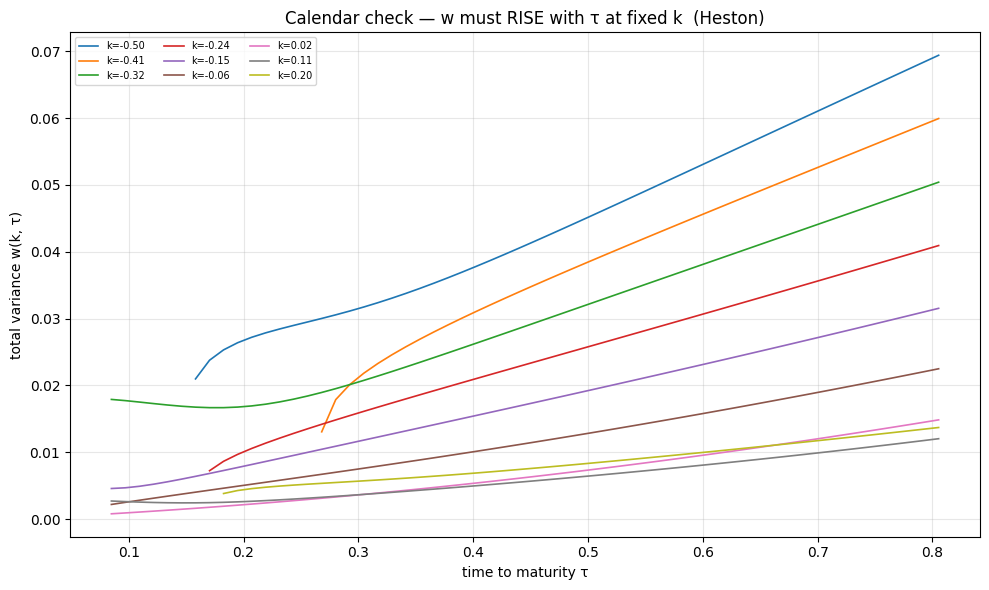

calendar slope violations (dw/dτ < 0) across the fixed-k lines: 12


<Figure size 640x480 with 0 Axes>

In [164]:
fig, ax = plt.subplots(figsize=(10, 6))

violations = 0
for k in k_levels:
    total_variance = heston_total_variance(
        k=k,tau_grid=tau_grid,S0=S0,r=r,v0=v0,kappa=kappa,theta=theta,xi=xi,rho=rho,
    )
    dwdt = np.diff(total_variance)
    violations += int((dwdt < 0).sum())

    # ax.plot(tau_grid, total_variance, marker="o", markersize=3, label=f"k = {k:.2f}",)
    ax.plot(tau_grid, total_variance, lw=1.2, label=f"k={k:.2f}")

ax.set_xlabel("time to maturity τ"); ax.set_ylabel("total variance w(k, τ)")
ax.set_title(f"Calendar check — w must RISE with τ at fixed k  (Heston)")
ax.legend(fontsize=7, ncol=3); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()
print(f"calendar slope violations (dw/dτ < 0) across the fixed-k lines: {violations}")

plt.tight_layout()
plt.show()

### Save results pickle

In [165]:
# ============================================================
# Save summary bundle: holdout predictions, RMSE, and arbitrage
# curves for both Heston calibrations (price-fit vs IV-fit)
#
# NOTE: this recomputes model-implied IV by inverting each method's own
# model price (test['heston_price'] / heston_price_ivfit) rather than
# reusing the existing test['heston_iv'] column above -- that column is
# inverted from market_prices (not the model price), so it doesn't
# actually reflect Heston fit quality. Data arrays are re-derived fresh
# from `test` here rather than reusing the loose strikes/ttes/spots/
# market_prices/option_types globals, since those were overwritten by
# the per-maturity plotting loop above and no longer span the full
# holdout set.
# ============================================================
import pickle, os

DRIVE = "training_results"
os.makedirs(DRIVE, exist_ok=True)

# METHODS = ["Heston (Price-fit)", "Heston (IV-fit)"]
METHODS = ["Heston (Price-fit)"]

# ---- 1) Model-implied IV on the holdout set, for both calibrations ---------
strikes_t = test["strike"].to_numpy(float)
ttes_t = test["tau"].to_numpy(float)
spots_t = test["underlying_last"].to_numpy(float)
option_types_t = test["type"].values

v0_iv, kappa_iv, theta_iv, xi_iv, rho_iv = result_iv.x

test["heston_price_ivfit"] = heston_price_vectorized(
    S0, strikes_t, ttes_t, v0_iv, r, kappa_iv, theta_iv, xi_iv, rho_iv, option_types_t
)

test["heston_iv_pricefit"] = bs_iv_vectorized(
    spots_t, strikes_t, ttes_t, r, test["heston_price"].to_numpy(float), option_types_t
)
test["heston_iv_ivfit"] = bs_iv_vectorized(
    spots_t, strikes_t, ttes_t, r, test["heston_price_ivfit"].to_numpy(float), option_types_t
)

rmse_price_fit = float(np.sqrt(np.mean((test["iv"] - test["heston_iv_pricefit"]) ** 2)))
# rmse_iv_fit = float(np.sqrt(np.mean((test["iv"] - test["heston_iv_ivfit"]) ** 2)))
# results = {"Heston (Price-fit)": rmse_price_fit, "Heston (IV-fit)": rmse_iv_fit}
results = {"Heston (Price-fit)": rmse_price_fit}

# ---- 2) Butterfly g(k) curve on the existing trimmed kline/tau_val ---------
predict_w_ivfit = make_heston_total_variance_predictor(
    S0=S0, r=r, v0=v0_iv, kappa=kappa_iv, theta=theta_iv, xi=xi_iv, rho=rho_iv,
)
# PREDICT_W = {"Heston (Price-fit)": predict_heston_w, "Heston (IV-fit)": predict_w_ivfit}
# PARAMS = {"Heston (Price-fit)": result_price.x, "Heston (IV-fit)": result_iv.x}
PREDICT_W = {"Heston (Price-fit)": predict_heston_w}
PARAMS = {"Heston (Price-fit)": result_price.x}

g_bundle = {"kline": kline, "tau_g": tau_val, "day": str(day.date()), "g": {}}
for name, pw in PREDICT_W.items():
    g_bundle["g"][name] = g_of(predict_w=pw, k=kline, tau=tau_val, eps=2e-3)

# ---- 3) Calendar total-variance curves on the existing k_levels/tau_grid ---
cal_bundle = {"tau_fine": tau_grid, "k_fixed": k_levels, "lines": {}}
for name, (v0_m, kappa_m, theta_m, xi_m, rho_m) in PARAMS.items():
    cal_bundle["lines"][name] = np.array([
        heston_total_variance(k=k0, tau_grid=tau_grid, S0=S0, r=r,
                               v0=v0_m, kappa=kappa_m, theta=theta_m, xi=xi_m, rho=rho_m)
        for k0 in k_levels
    ])

# ---- 4) Arbitrage violation counts, per method ------------------------------
arb = {}
for name in METHODS:
    g_vals = g_bundle["g"][name]
    finite = np.isfinite(g_vals)
    cal_viol = int(sum((np.diff(line) < 0).sum() for line in cal_bundle["lines"][name]))
    arb[name] = {
        "butterfly_min_g": float(np.nanmin(g_vals)),
        "butterfly_violations": int(np.sum(g_vals[finite] < -1e-6)),
        "calendar_violations": cal_viol,
    }

# ---- 5) Holdout predictions table -------------------------------------------
hold = test[["quote_date", "expire_date", "dte", "tau", "log_moneyness", "iv"]].copy()
hold["heston_iv_pricefit"] = test["heston_iv_pricefit"].values
hold["heston_iv_ivfit"] = test["heston_iv_ivfit"].values
hold = hold.reset_index(drop=True)

# ---- 6) Assemble the bundle --------------------------------------------------
summary_bundle = {
    "ticker": TICKER,
    "methods": METHODS,

    "hold": hold,
    "rmse": results,
    "arb": arb,

    "g_curve": g_bundle,
    "cal_curve": cal_bundle,

    # "pnl": {},
    # "money": [],
    # "hedge_stats": {},
}

# ---- 7) Save + verify ---------------------------------------------------------
path = f"{DRIVE}/summary_bundle_Heston_{TICKER}_{QUOTE_DATE}.pkl"
pickle.dump(summary_bundle, open(path, "wb"))

print("saved:", path)
print(f"  hold rows   : {len(summary_bundle['hold'])}")
print(f"  rmse        : {summary_bundle['rmse']}")
print(f"  arb         : {'OK' if summary_bundle['arb'] else 'EMPTY'}")
print(f"  g_curve     : {'OK' if summary_bundle['g_curve']['g'] else 'EMPTY'}")
print(f"  cal_curve   : {'OK' if summary_bundle['cal_curve']['lines'] else 'EMPTY'}")
# print(f"  pnl         : {'OK (' + str(len(summary_bundle['pnl'])) + ' arrays)' if summary_bundle['pnl'] else 'EMPTY  (no hedge run in this notebook)'}")


saved: training_results/summary_bundle_Heston_SPX_2023-12-29.pkl
  hold rows   : 186
  rmse        : {'Heston (Price-fit)': 0.012557669925122245}
  arb         : OK
  g_curve     : OK
  cal_curve   : OK
